Site Model Multiple Regression Weekly

In [2]:
from datetime import datetime
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator, PercentFormatter
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import zscore, linregress
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import scale, PolynomialFeatures
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
import os

#%run plotting/multiple_regression.ipynb
#%run plotting/multiple_regression_updated.ipynb
%run plotting/multiple_regression_updated_metadata.ipynb


# Change the working directory
os.chdir(r'C:\Users\aotis\OneDrive - THE CHRONICLE OF HIGHER EDUCATION\Documents\Python Scripts Data\Model')

In [3]:
# Read the CSV file
df = pd.read_csv('Parse.ly API Full Site Model Data - Weekly.csv')

# Set filters for the regression

# Set the date range. 
start_date = '2023-11-01' # start date (inclusive)
end_date = '2026-04-27'   # end date (exclusive)

# Convert publish date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Filter rows within the date range
df = df[(df['Date'] >= start_date) & (df['Date'] < end_date)]

# Set section for chart titles. Leave blank if using all sections. Add a space after a section for correct formatting
section = "" # News , The Review , Advice 

# Set the charts' color. #0f2c55 is chronicle blue for all sections, skyblue is News, #77dd77 is The Review, salmon is Advice
color = '#0f2c55'

# Set minimum sample count for each independent variable. Variables used less than this min sample count are not analyzed.
''' Individual sample size should be at least 15 per each independent variable (Stevens (1996, p. 72))
Total sample size should be above 50 + 8 * number of independent variables (Tabachnick and Fidell (2013, p. 123)) '''
min_sample_count = 10

# Set unique value threshold. Variables with unique values below the threshold are not checked for outliers
unique_value_threshold = 10

# Set plotting threshold. Variables with unique values below the threshold are not scatter-plotted
plotting_threshold = 3

# Set outlier threshold for independent variables (standard deviations from the mean). Currently set high to not overly trim the df
independent_variable_outlier_threshold = 3

# Set outlier threshold for dependent variables (standard deviations from the mean)
dependent_variable_outlier_threshold = 3

# Set the significance level for the independent variables in the regression. 0.05 recommended (p < .05)
significance_level = 0.1

# Set the correlation threshold at which a scatterplot or line plot is used.
# A scatterplot is used for correlations below the threshold, a line plot for correlations above the threshold
line_plot_threshold = 0.15

# Set the factor at which the next level polynomial degree is preferred when plotting a best fit line in a regression 
# Formatted as a decmial: 1.10 = 10%. The next degree is used if it fits 10% better than the lower degree
'''Too too high a value can lead to incorrectly representing data, too low a value can lead to overfitting'''
best_fit_improvement_factor = 2

# Define variance categories that are used in variance explained table
variance_categories = {

}

In [4]:
# ======================
# Check to remove weeks where fewer than X articles were published (e.g. holidays)
# ======================

# Filter below which rows are removed
row_filter = 10

# Identify rows that will be removed
removed_rows = df[df["Content Type: Article | Posts Published"] < row_filter]

# Get the first column for printing
first_cols = removed_rows.iloc[:, :1]

# Print the removed rows (first two columns only)
print(f"Rows removed because fewer than {row_filter} articles were published:")
print(first_cols)

# Apply the filter to keep only rows with more than 10 articles
df = df[df["Content Type: Article | Posts Published"] >= row_filter].reset_index(drop=True)


Rows removed because fewer than 10 articles were published:
          Date
8   2023-12-31
21  2024-03-31
56  2024-12-01
60  2024-12-29
61  2025-01-05
87  2025-07-06
94  2025-08-24
108 2025-11-30
112 2025-12-28
113 2026-01-04


In [5]:
# =============================
# Set independent variables for regression
# =============================

independent_variables = [
    
# Content Types Posts Published
    'Content Type: Article | Posts Published',
    #'Content Type: Blog | Posts Published',
    #'Content Type: Newsletter | Posts Published',
    'Articles & Blogs Published',

# Section Posts Published
    #'Section: Academe Today | Posts Published', 
    #'Section: Afternoon Update | Posts Published', 
    #'Section: Breaking News | Posts Published', 
    #'Section: College Matters from The Chronicle | Posts Published', 
    #'Section: Daily Briefing | Posts Published', 
    #'Section: Latitudes | Posts Published', 
    #'Section: Letters | Posts Published', 
    #'Section: Sponsored Content | Posts Published', 
    #'Section: Teaching | Posts Published', 
    #'Section: The Edge | Posts Published', 
    #'Section: The Trump Agenda | Posts Published', 
    #'Section: Uncategorized | Posts Published', 
    #'Section: Weekly Briefing | Posts Published',
    
# Content Types Words Published
    #'Content Type: Article | Words Published', 
    
# Content Types Mean Words Published
    #'Content Type: Article | Mean Words Per Post',
    'Article Word Count Mean',
    'Article Word Count Standard Deviation',
    'Percent of Articles Above Q3 Words',
    'Percent of Articles Below Q1 Words',
    
# Section Words Published
    #'Section: Academe Today | Words Published', 
    #'Section: Afternoon Update | Words Published', 
    #'Section: Breaking News | Words Published', 
    #'Section: College Matters from The Chronicle | Words Published', 
    #'Section: Daily Briefing | Words Published', 
    #'Section: Latitudes | Words Published', 
    #'Section: Letters | Words Published', 
    #'Section: Sponsored Content | Words Published', 
    #'Section: Teaching | Words Published', 
    #'Section: The Edge | Words Published', 
    #'Section: The Trump Agenda | Words Published', 
    #'Section: Uncategorized | Words Published', 
    #'Section: Weekly Briefing | Words Published',
    
    # Total Tags
    #'Content Type: Article | Total Tags', 
    
    # Unique Tags
    'Content Type: Article | Mean Unique Tags per Day', 
    'Editorial Tags Used At Least 3 Times',
    'Editorial Tags Used At Least 2 Times',
    'Editorial Tags Used At Least 1 Time',

    #"Article Unique Tag Ratio",
    #"Article Total Tag Ratio",

    # External Factors
    #'Presidential Administration',

    # Internal Factors
    #'Free Content Views',
]

# List of columns not in the DataFrame
missing_columns = [col for col in independent_variables if col not in df.columns]

# Print missing columns, if any
if missing_columns:
    print("These columns are missing from the DataFrame and will be not be included in the analysis:")
    for col in missing_columns:
        print(col)
        
independent_variables = [col for col in independent_variables if col in df.columns]

In [6]:
# =============================
# Set dependent variables for regression to iterate through
# =============================

dependent_variables = [

'Page Views',
#'Views On Posts',
#"Active Users",
#"Visitors On Posts",
#"Minutes",
"Engaged Minutes On Posts",
#'Paywall Views',
#'Paywall Active Users',
'Account Registrations',
#'Account Registration | Linear Conversions',
#"Account Registration Efficiency",
"Account Registration Efficiency | Linear Conversions",
'Subscriptions',
#'Subscriptions | Linear Conversions',
#'Subscriptions | Last Touch Visitors',
#"Subscription Efficiency",
"Subscription Efficiency | Linear Conversions",
'Recirculation Rate',
    
#'Site Licensees | Engaged Minutes On Posts',
#'Individual Subscribers | Engaged Minutes On Posts',
#'Non Registrants | Views On Posts',   
#'Non Registrants | Visitors On Posts',
]

# List of columns not in the DataFrame
missing_columns = [col for col in dependent_variables if col not in df.columns]

# Print missing columns, if any
if missing_columns:
    print("These columns are missing from the DataFrame and will be not be included in the analysis:")
    for col in missing_columns:
        print(col)

dependent_variables = [col for col in dependent_variables if col in df.columns]

In [7]:
# ----------------------
# Remove outliers from continuous Independent Variables which have more unique values than a threshold. 
# This is done to not be overly aggressive in removing outliers in certain columns (e.g. binary columns).
# ----------------------

# Initialize a dictionary to store the number of rows removed for each column
rows_removed_by_column = {}
removed_rows_list = []

# Loop through each independent variable
for column in df[independent_variables].columns:
    unique_count = df[column].nunique()
    
    if unique_count > unique_value_threshold:
       
        # Calculate the z-scores
        z_scores = zscore(df[column])
        
        # Identify outliers as those with absolute z-scores greater than the threshold
        outliers = np.abs(z_scores) > independent_variable_outlier_threshold
        
        # Store the rows that will be removed
        removed_rows_list.append(df[outliers])
        
        # Count rows before removing outliers for this column
        rows_before = len(df)
        
        # Remove outliers by keeping only the rows where z-score is <= threshold
        df = df[~outliers]
        
        # Count rows after removing outliers for this column
        rows_after = len(df)
        
        # Calculate the number of rows removed for this column and store it
        rows_removed_by_column[column] = rows_before - rows_after

# Concatenate all removed rows into a single DataFrame
if removed_rows_list:
    removed_rows_df = pd.concat(removed_rows_list).drop_duplicates().reset_index(drop=True)
else:
    removed_rows_df = pd.DataFrame(columns=df.columns)

# Reset index after removing rows
df = df.reset_index(drop=True)

# Print the number of rows removed due to each column's outliers
for column, removed in rows_removed_by_column.items():
    print(f"{removed} rows removed because of outliers in '{column}'")

# Print the rows that were removed
# Print just the first column of rows removed
first_column_name = removed_rows_df.columns[0]
print(removed_rows_df[first_column_name])


1 rows removed because of outliers in 'Content Type: Article | Posts Published'
0 rows removed because of outliers in 'Articles & Blogs Published'
1 rows removed because of outliers in 'Article Word Count Mean'
0 rows removed because of outliers in 'Article Word Count Standard Deviation'
1 rows removed because of outliers in 'Percent of Articles Above Q3 Words'
0 rows removed because of outliers in 'Percent of Articles Below Q1 Words'
0 rows removed because of outliers in 'Content Type: Article | Mean Unique Tags per Day'
1 rows removed because of outliers in 'Editorial Tags Used At Least 3 Times'
1 rows removed because of outliers in 'Editorial Tags Used At Least 2 Times'
0 rows removed because of outliers in 'Editorial Tags Used At Least 1 Time'
0   2025-09-14
1   2024-06-09
2   2026-04-05
3   2024-03-24
4   2023-12-10
Name: Date, dtype: datetime64[ns]


In [8]:
# --------------------------------
# Remove columns that have a sample count below min_sample_count
# --------------------------------

# Count occurrences of each column
column_counts = df[independent_variables].sum()

# Identify columns to keep
kept_columns = column_counts[column_counts >= min_sample_count].index.tolist()

# Identify columns that will be removed
removed_columns = [col for col in independent_variables if col not in kept_columns]

# Update the independent_variables list
#independent_variables = kept_columns

# Print removed columns
print("Removed the following columns because they are used too infrequently as independent variables:")
print(removed_columns)

Removed the following columns because they are used too infrequently as independent variables:
[]


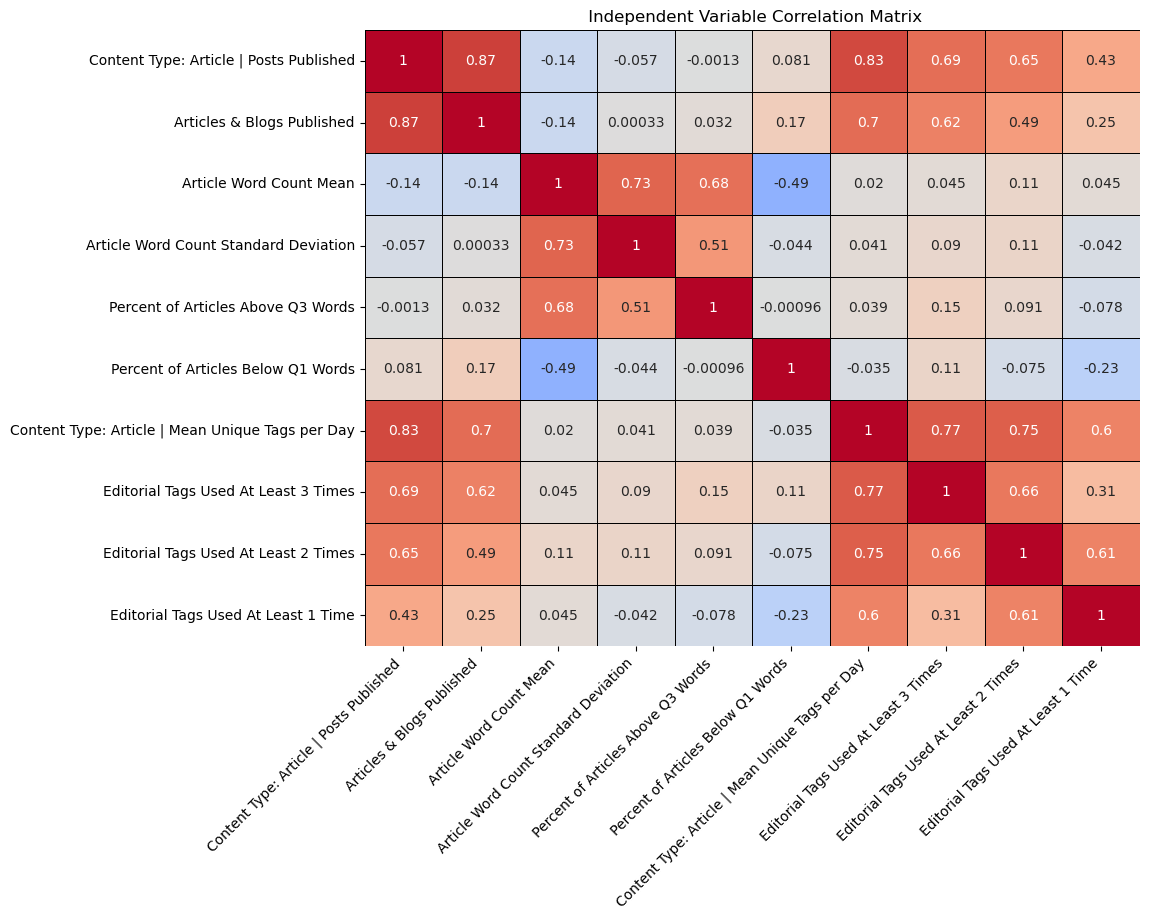

In [9]:
# --------------------------------
# Create a correlation matrix of the dependent variables
# --------------------------------

# Calculate the correlation matrix for the selected variables
correlation_matrix = df[independent_variables].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Plot the heatmap with Seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='black', cbar=False)

# Set title and display options
plt.title(f"{section} Independent Variable Correlation Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Save and display the image
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

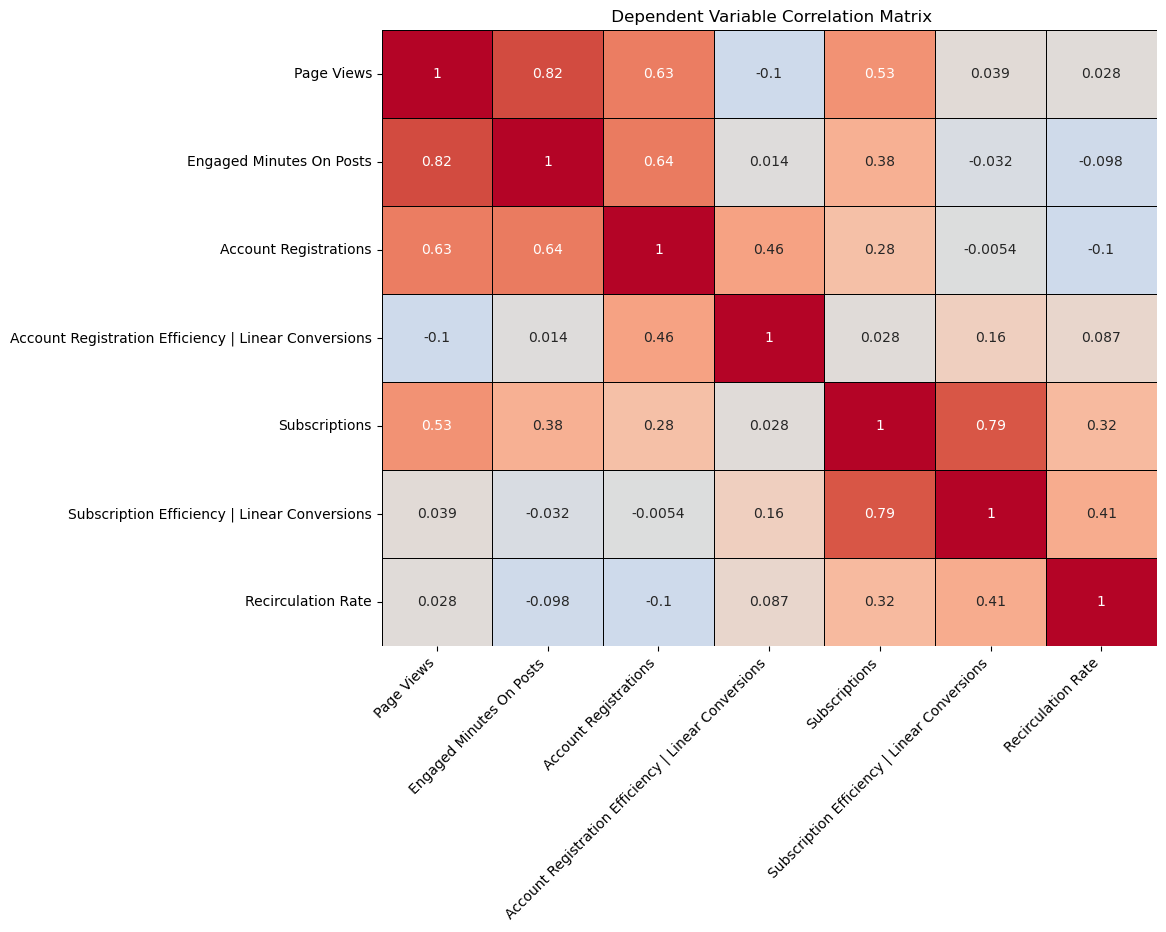

In [10]:
# --------------------------------
# Create a correlation matrix of the dependent variables
# --------------------------------

# Calculate the correlation matrix for the selected variables
correlation_matrix = df[dependent_variables].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Plot the heatmap with Seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='black', cbar=False)

# Set title and display options
plt.title(f"{section} Dependent Variable Correlation Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Save and display the image
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

1 rows removed due to outliers in 'Page Views'. 114 rows analyzed
                            OLS Regression Results                            
Dep. Variable:             Page Views   R-squared:                       0.389
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     6.556
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           8.81e-08
Time:                        11:08:11   Log-Likelihood:                -1388.4
No. Observations:                 114   AIC:                             2799.
Df Residuals:                     103   BIC:                             2829.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

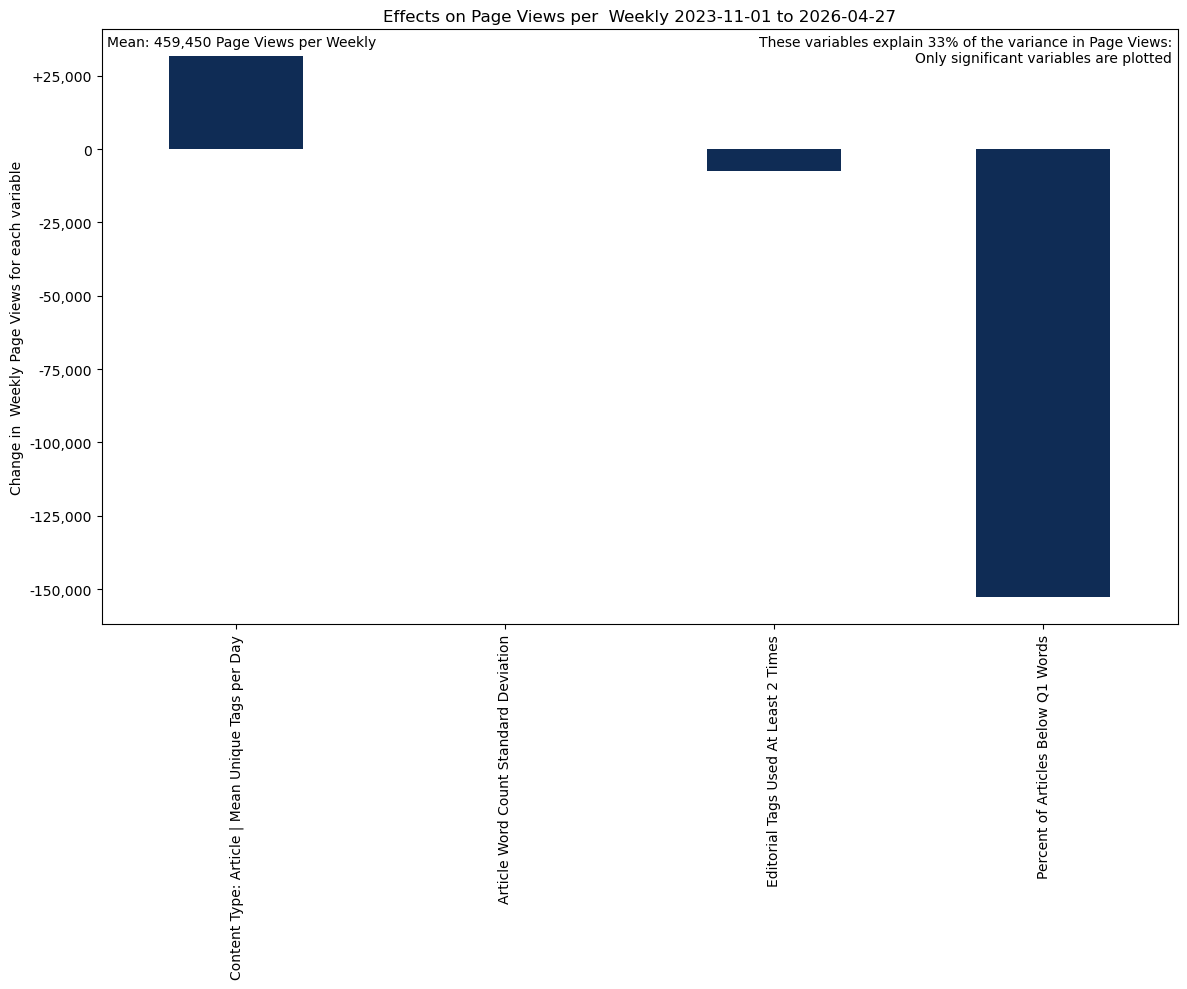

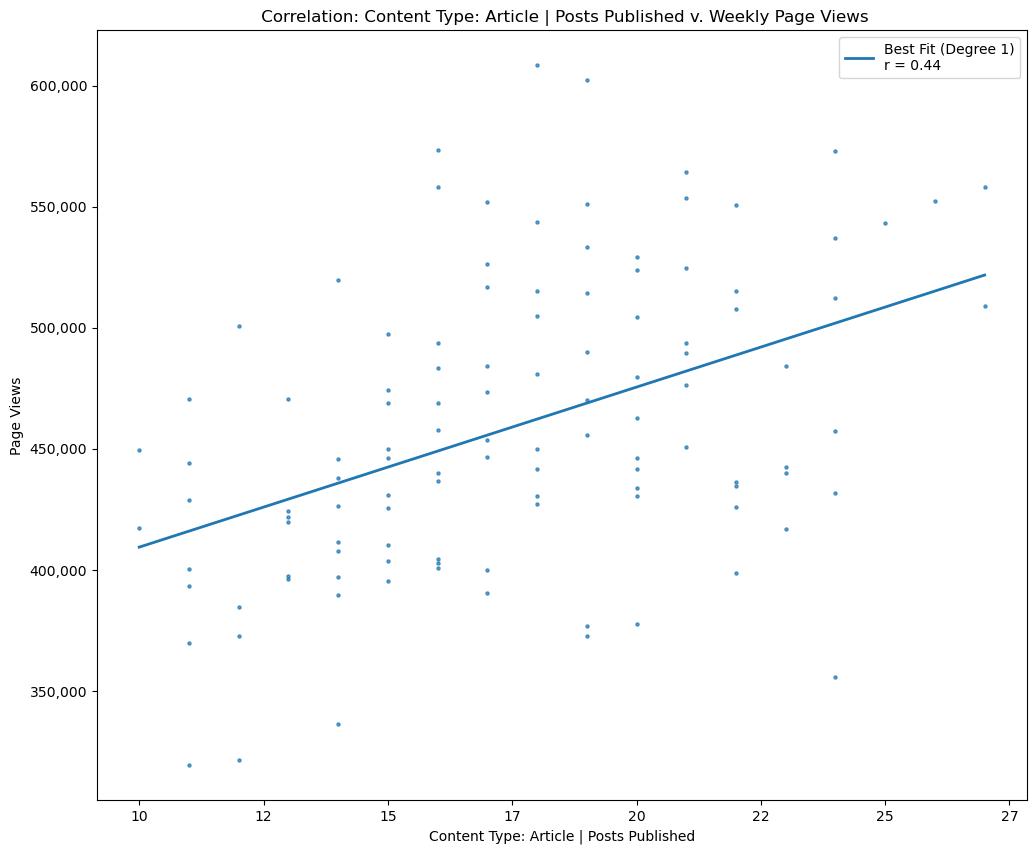

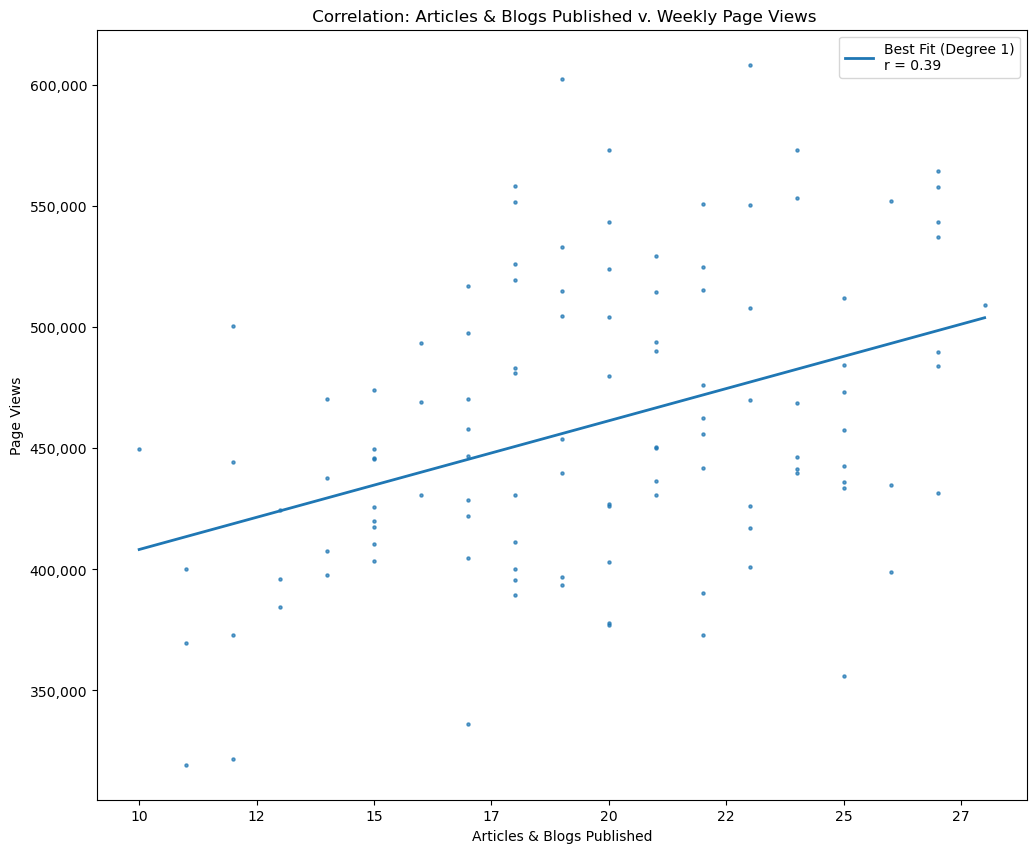

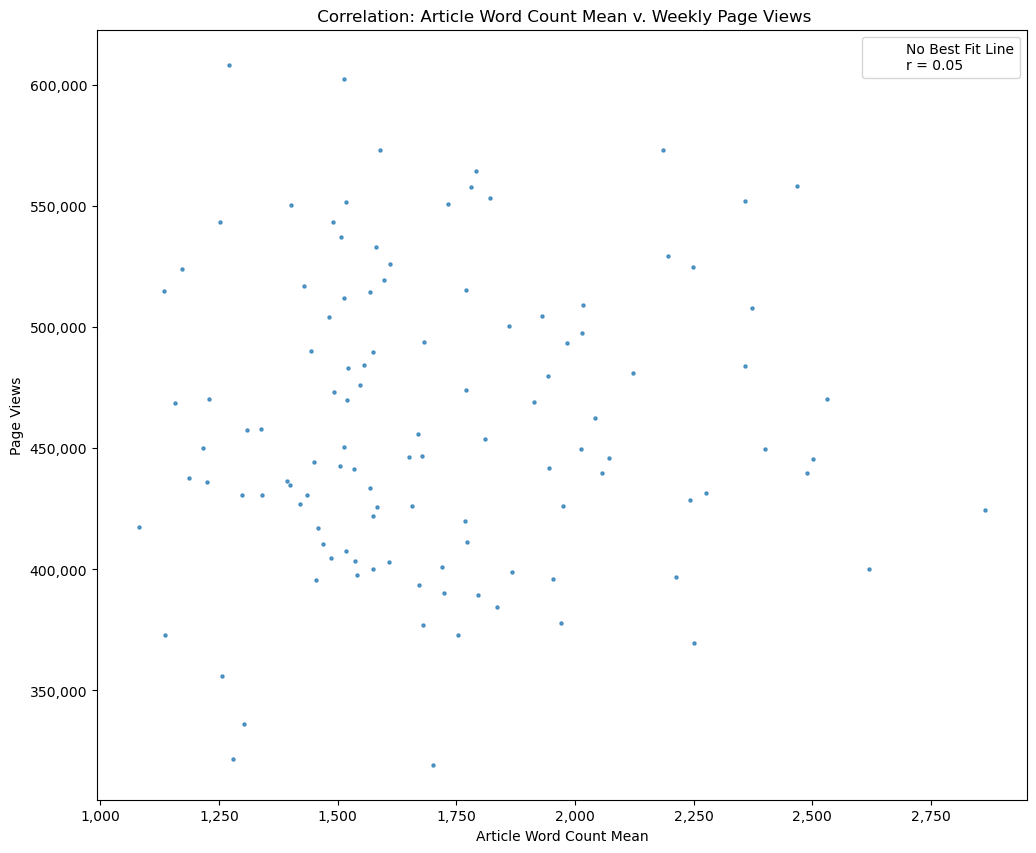

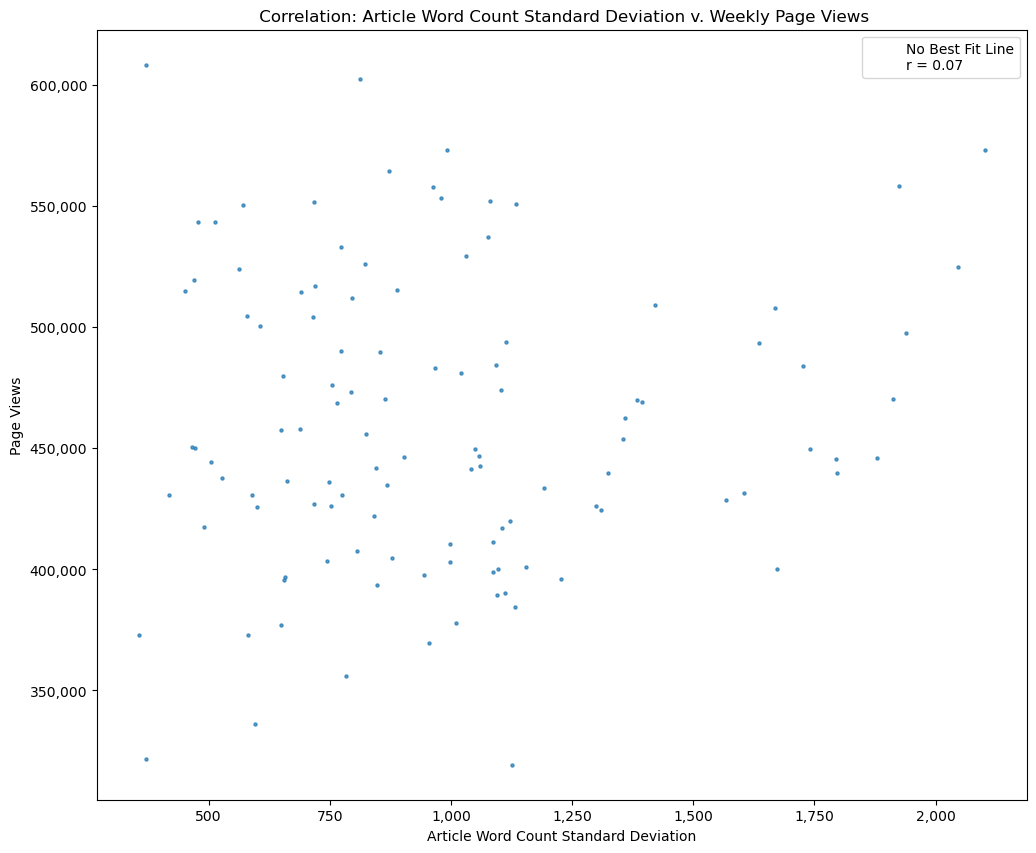

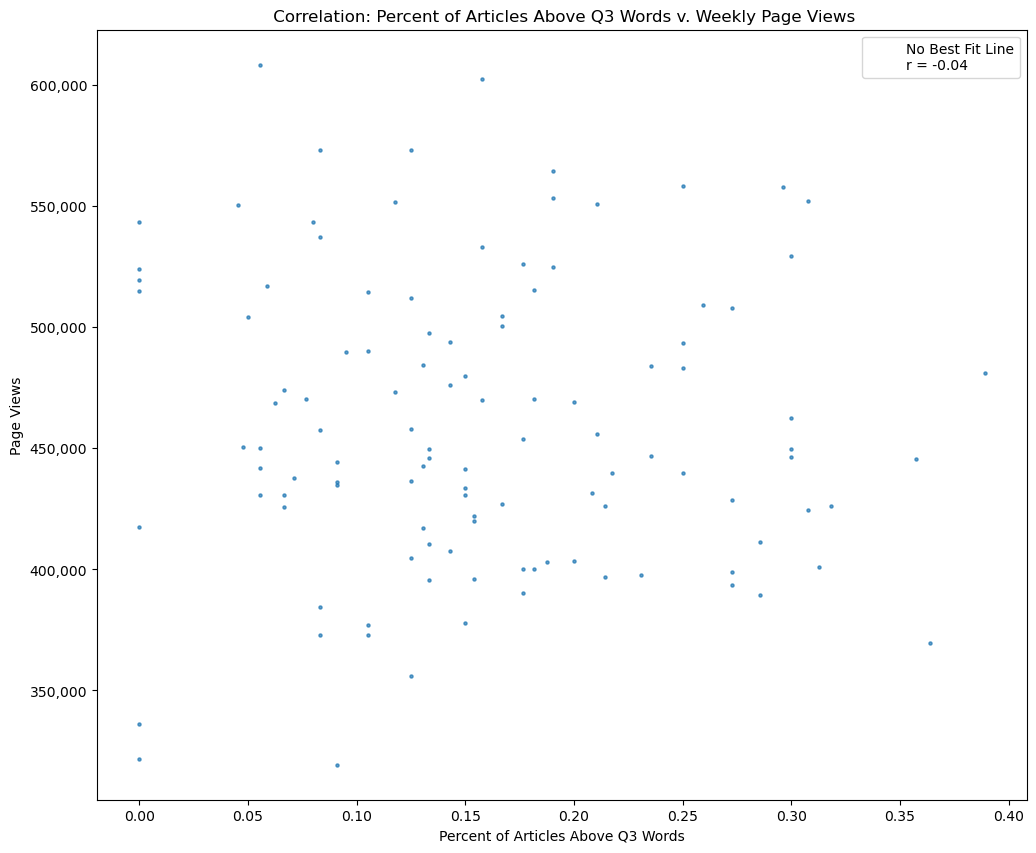

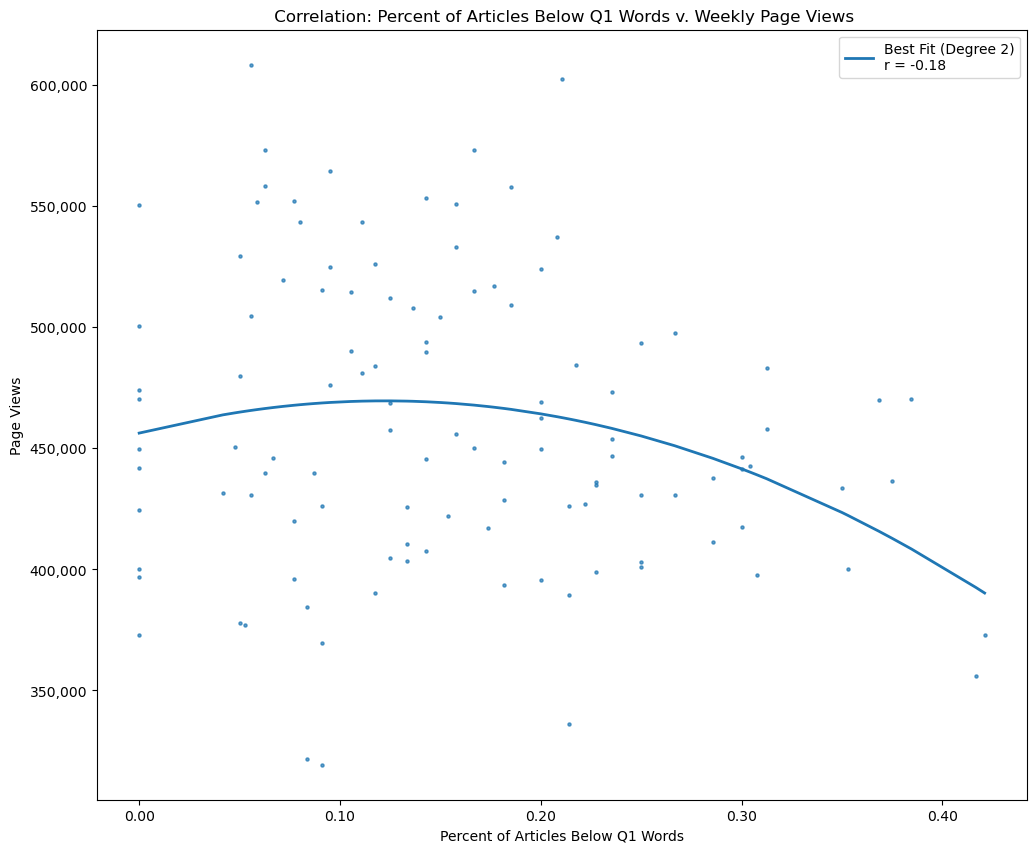

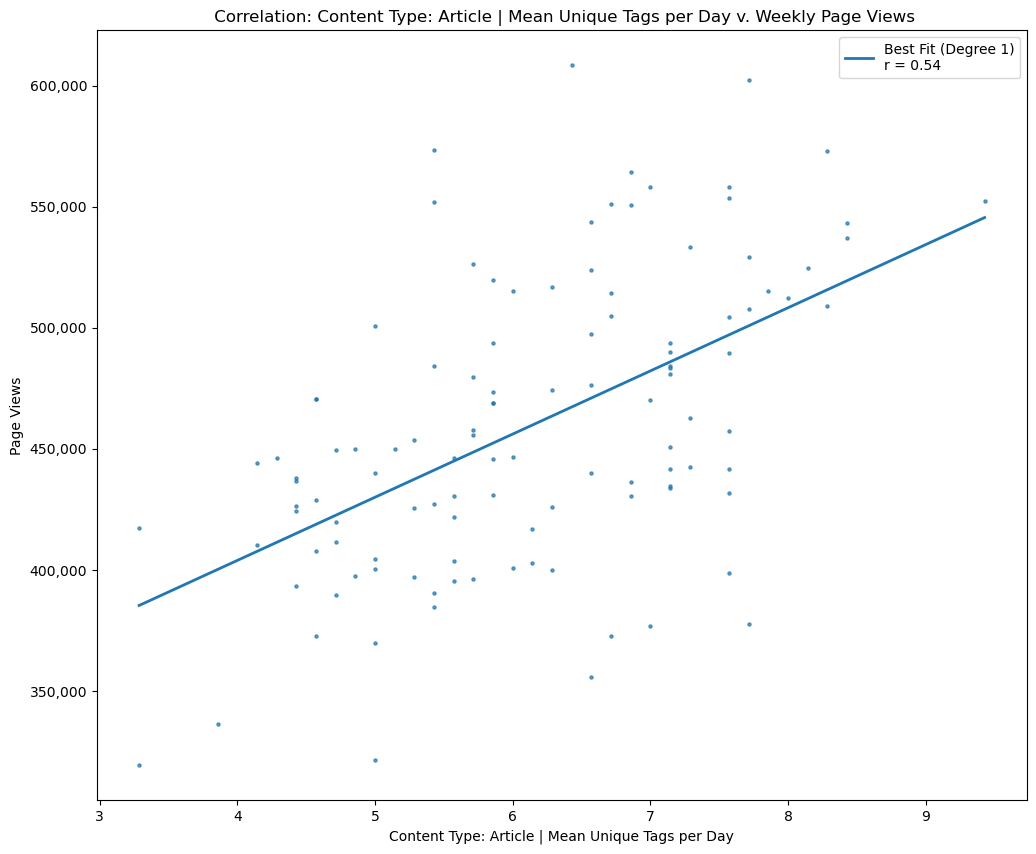

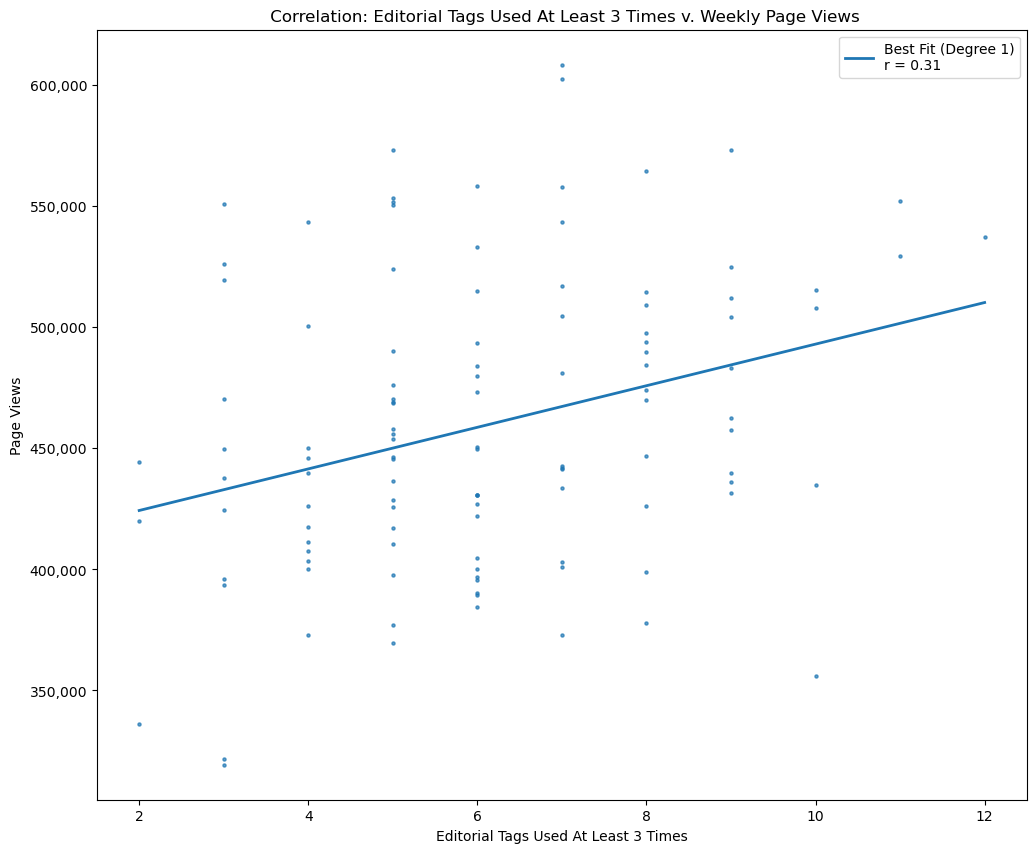

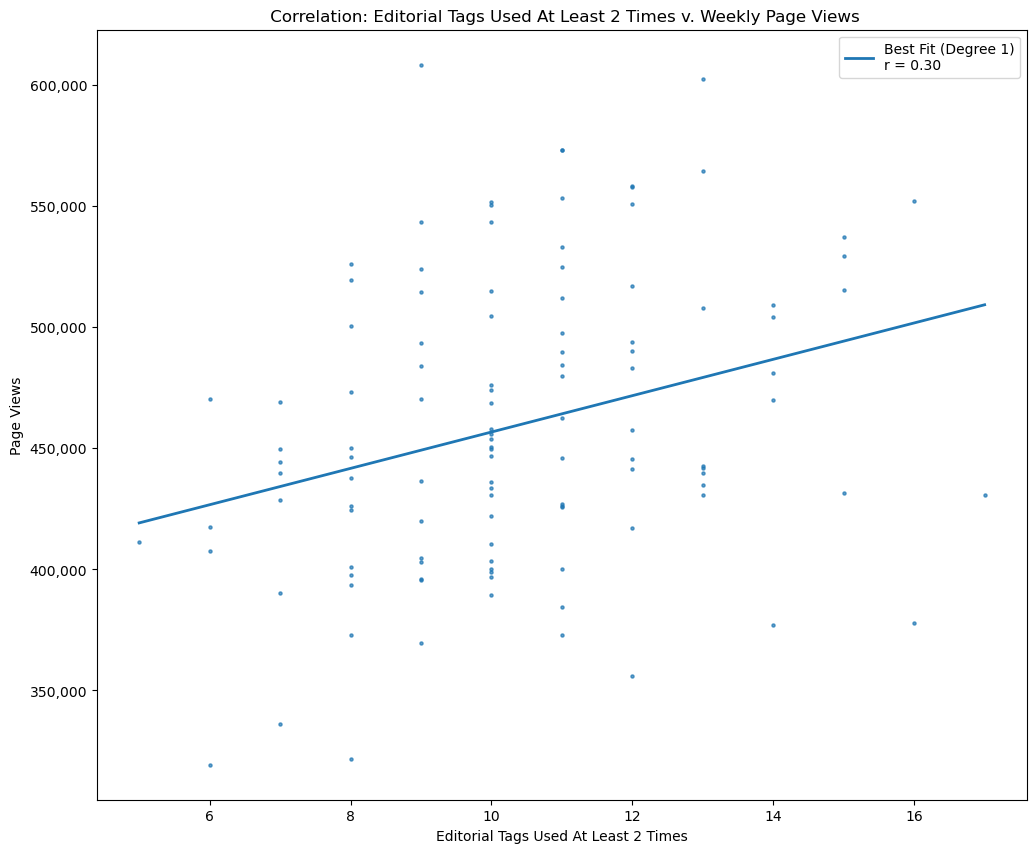

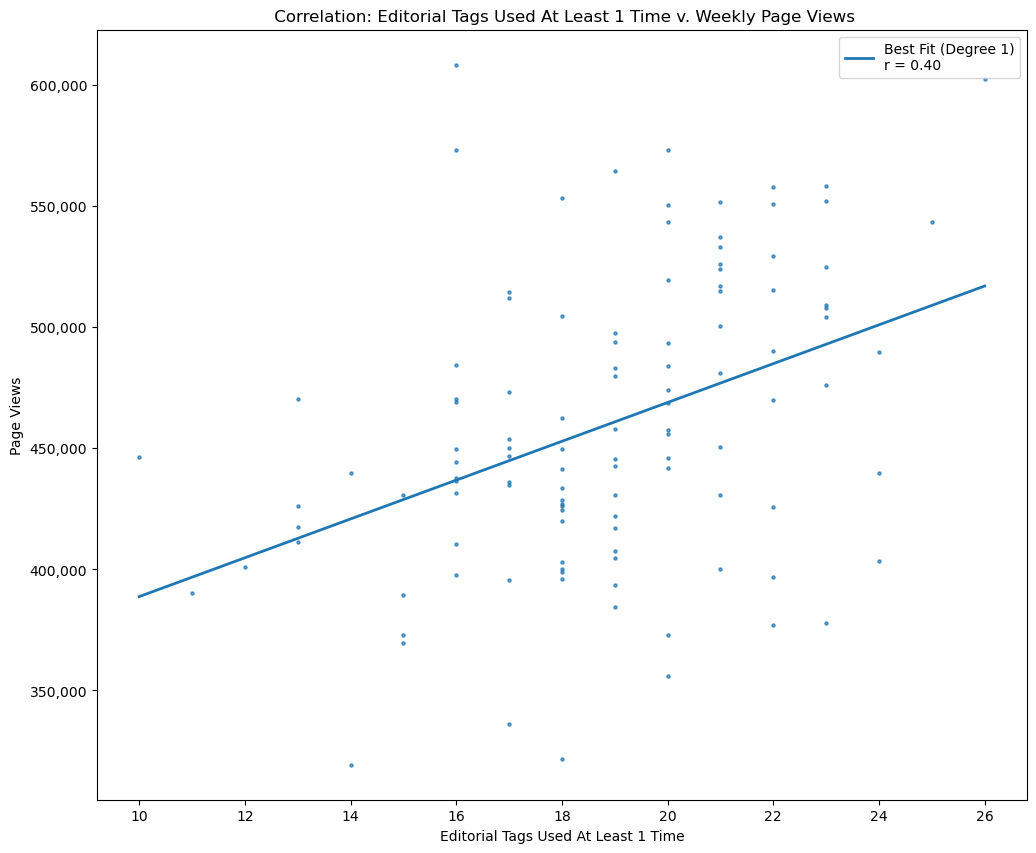

0 rows removed due to outliers in 'Engaged Minutes On Posts'. 115 rows analyzed
                               OLS Regression Results                               
Dep. Variable:     Engaged Minutes On Posts   R-squared:                       0.280
Model:                                  OLS   Adj. R-squared:                  0.211
Method:                       Least Squares   F-statistic:                     4.049
Date:                      Tue, 28 Apr 2026   Prob (F-statistic):           0.000104
Time:                              11:08:13   Log-Likelihood:                -1365.1
No. Observations:                       115   AIC:                             2752.
Df Residuals:                           104   BIC:                             2782.
Df Model:                                10                                         
Covariance Type:                  nonrobust                                         
                                                       coef    std err

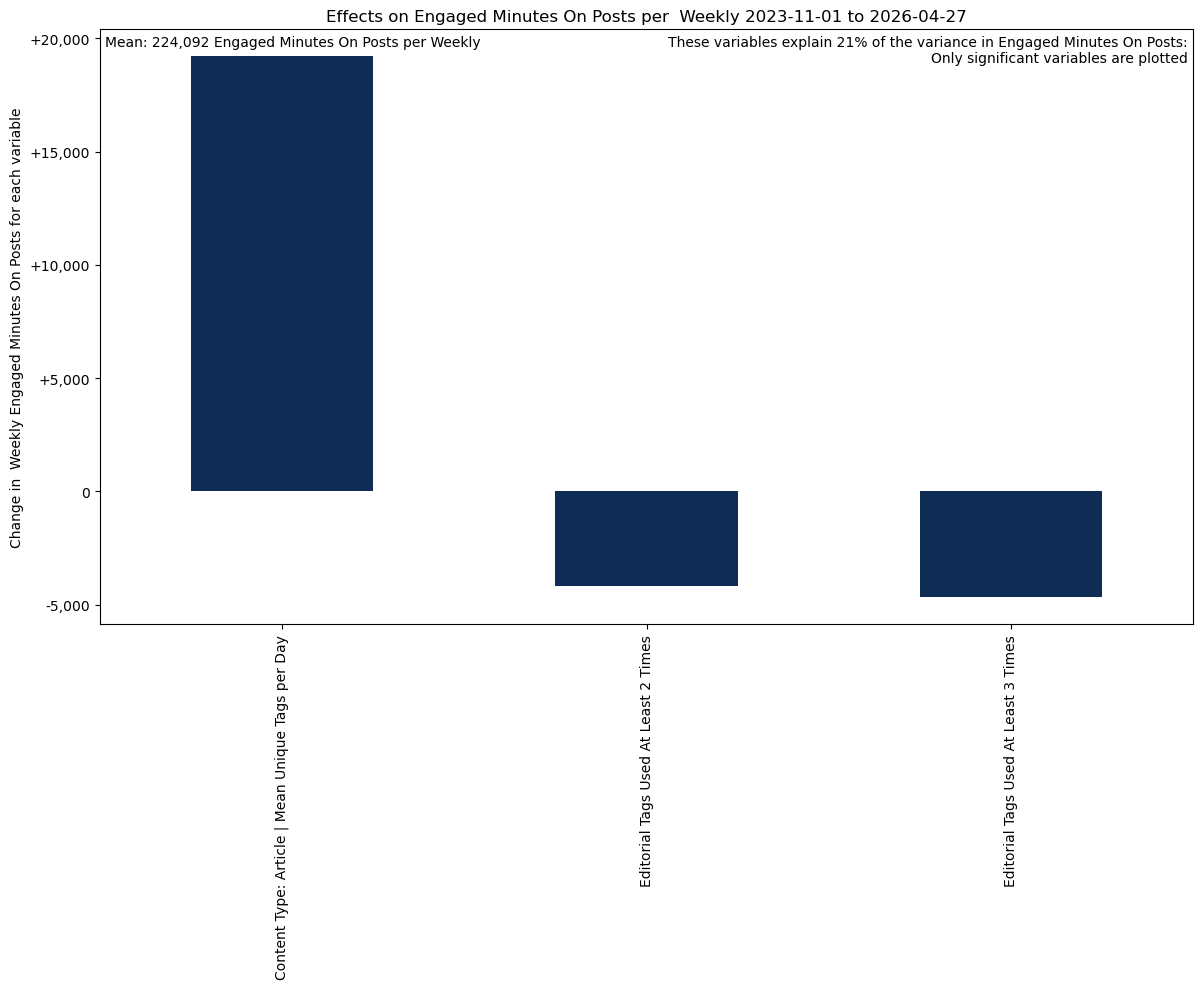

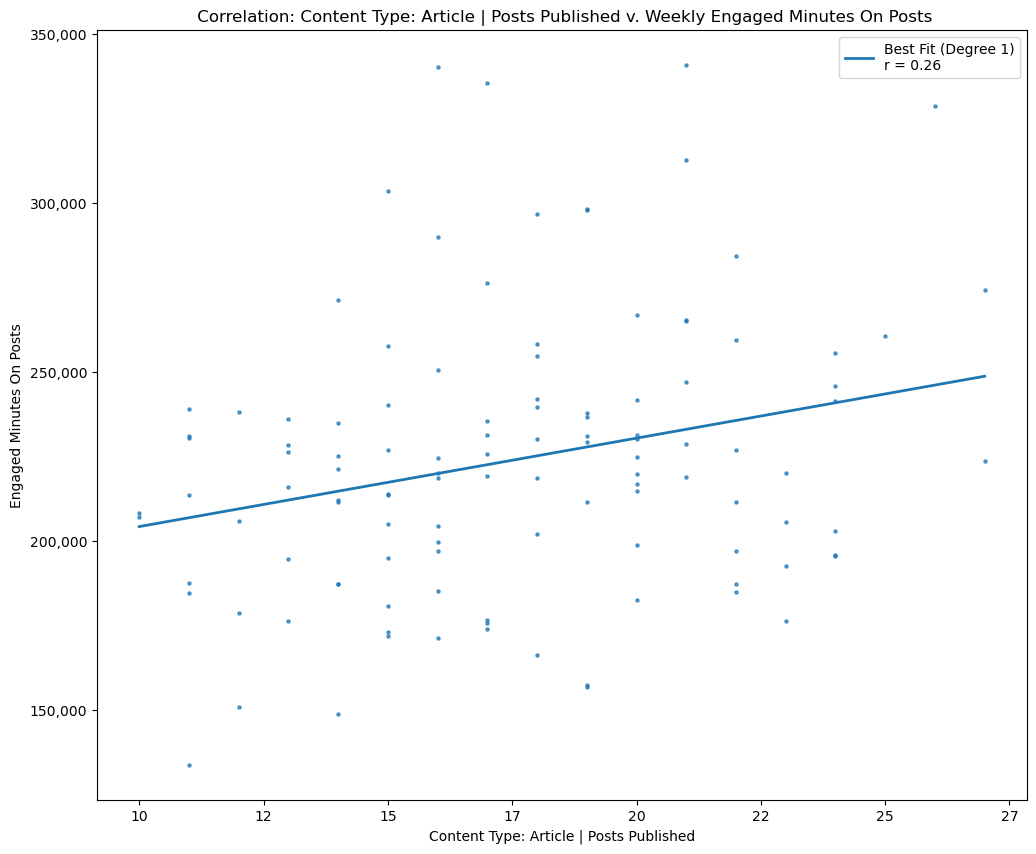

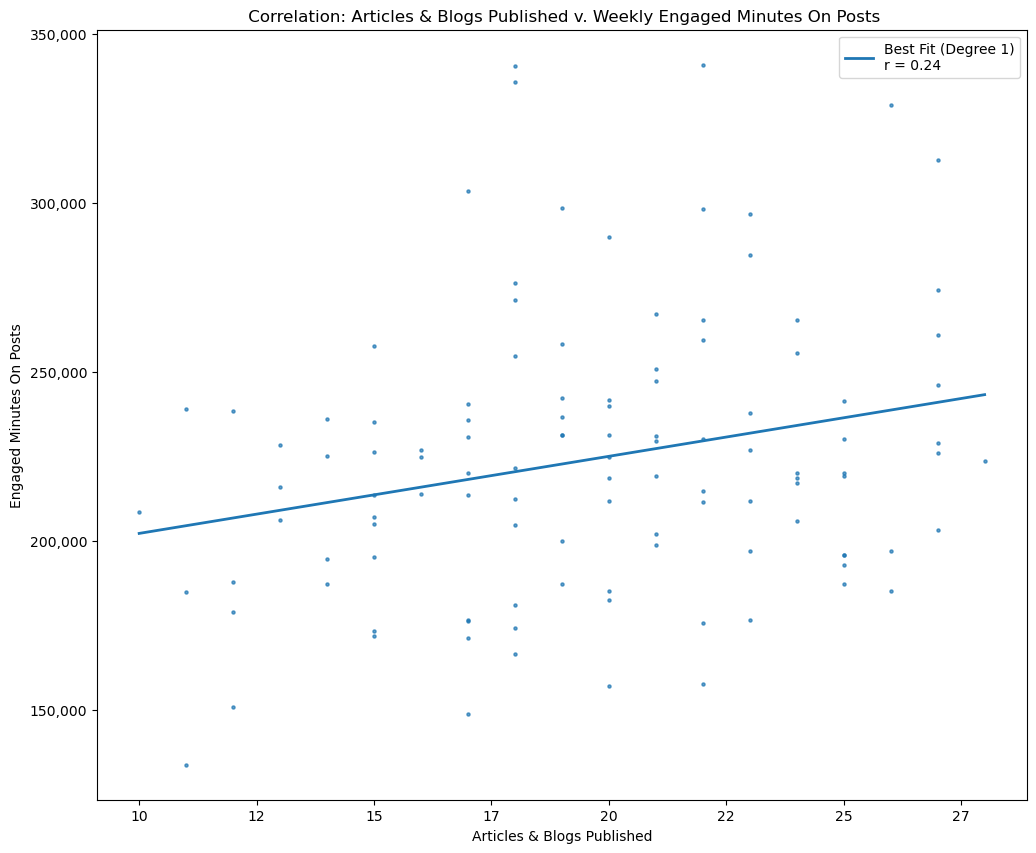

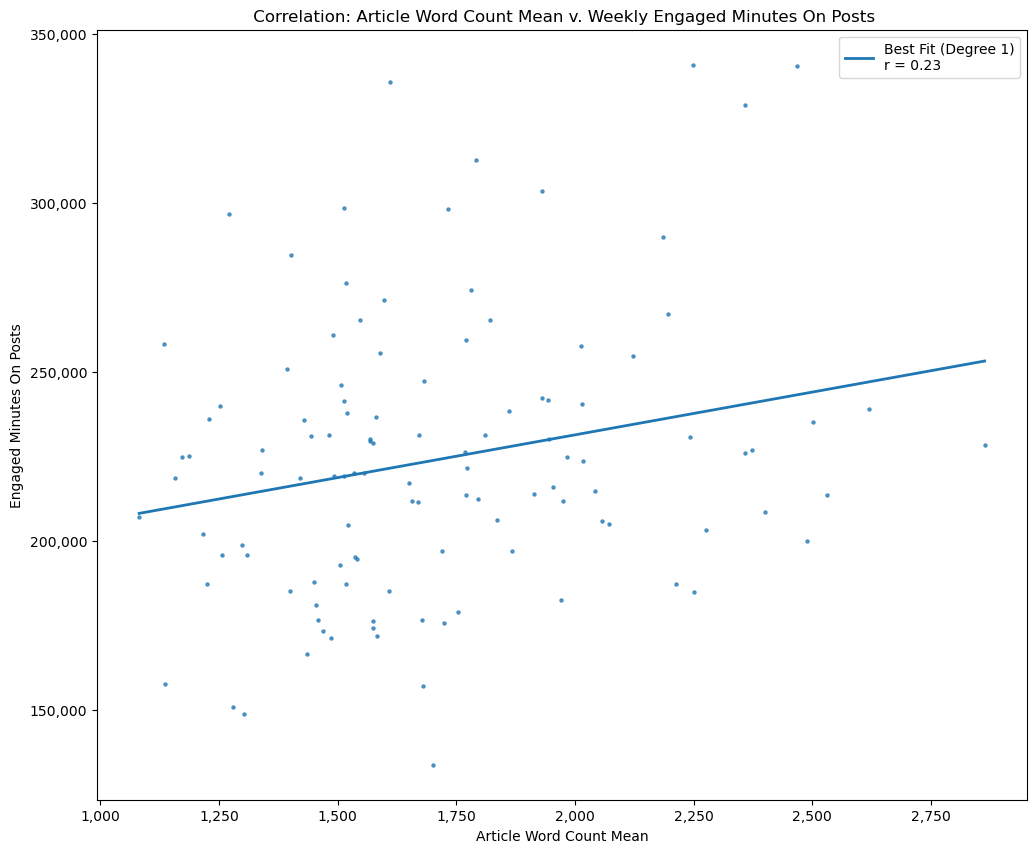

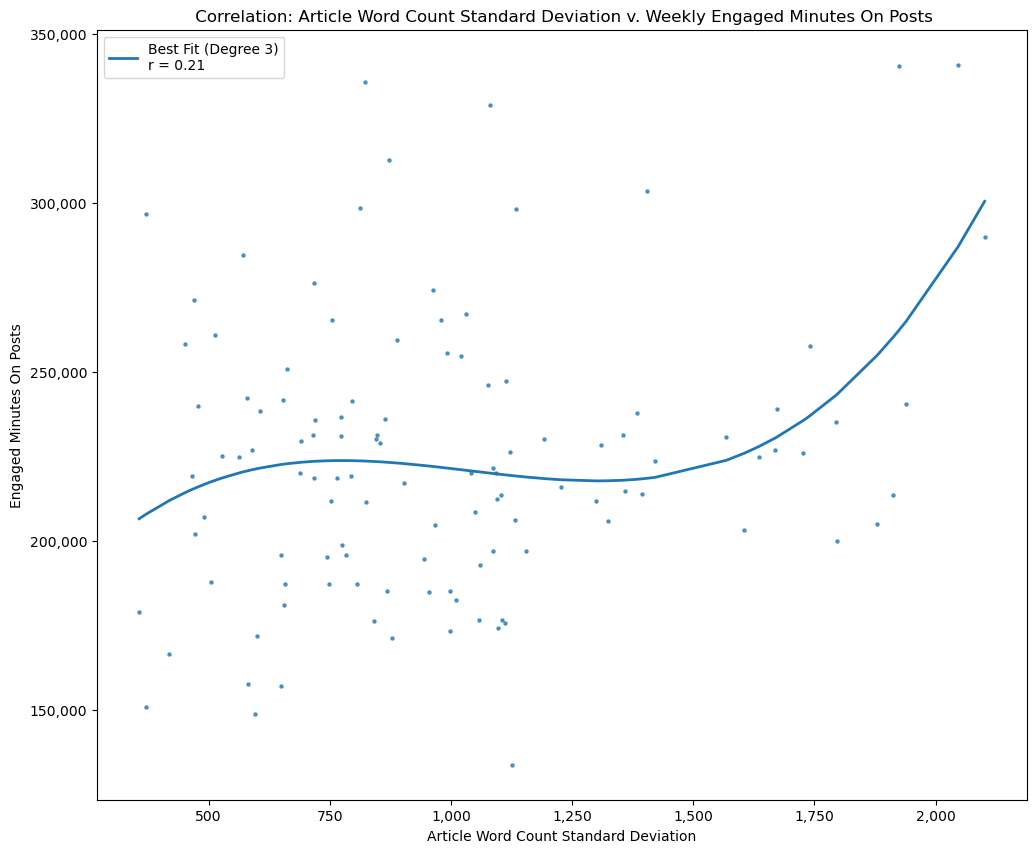

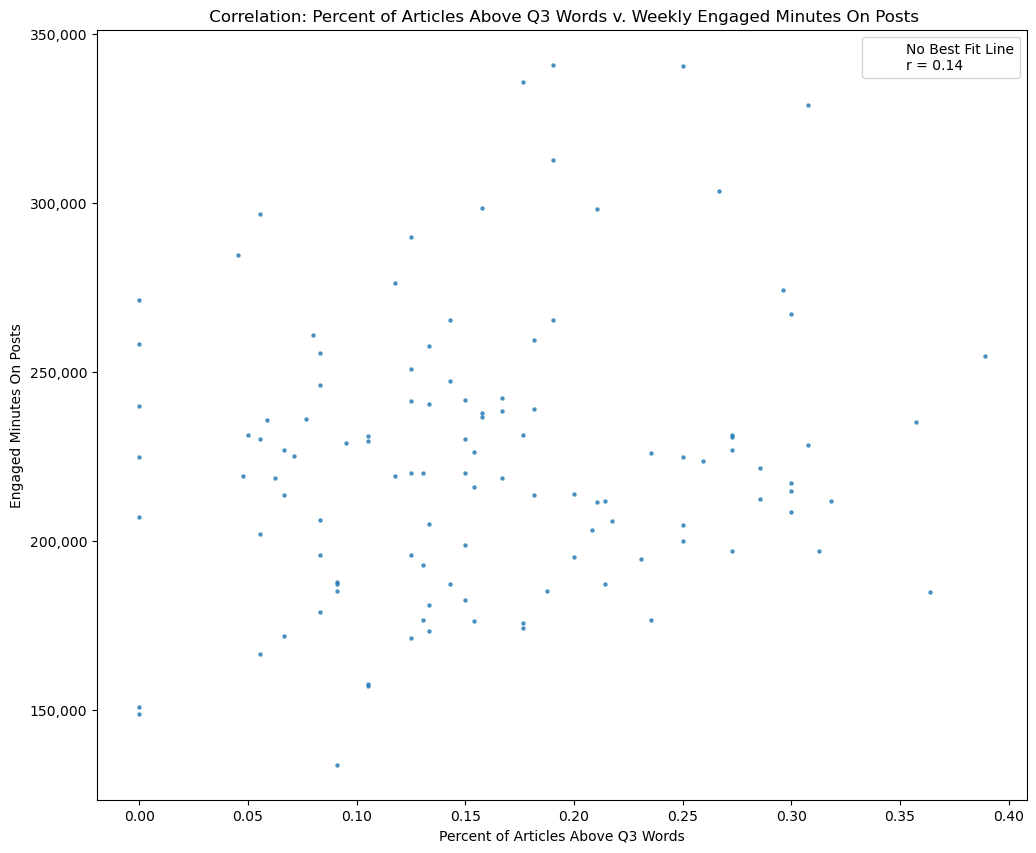

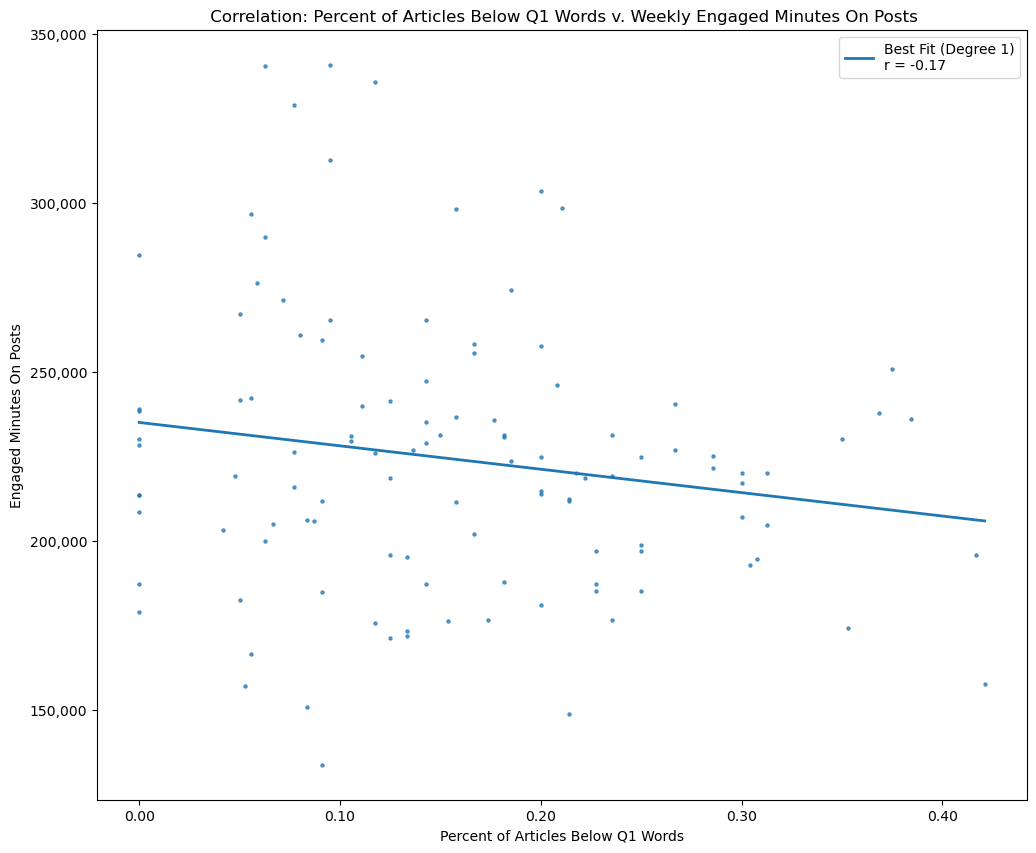

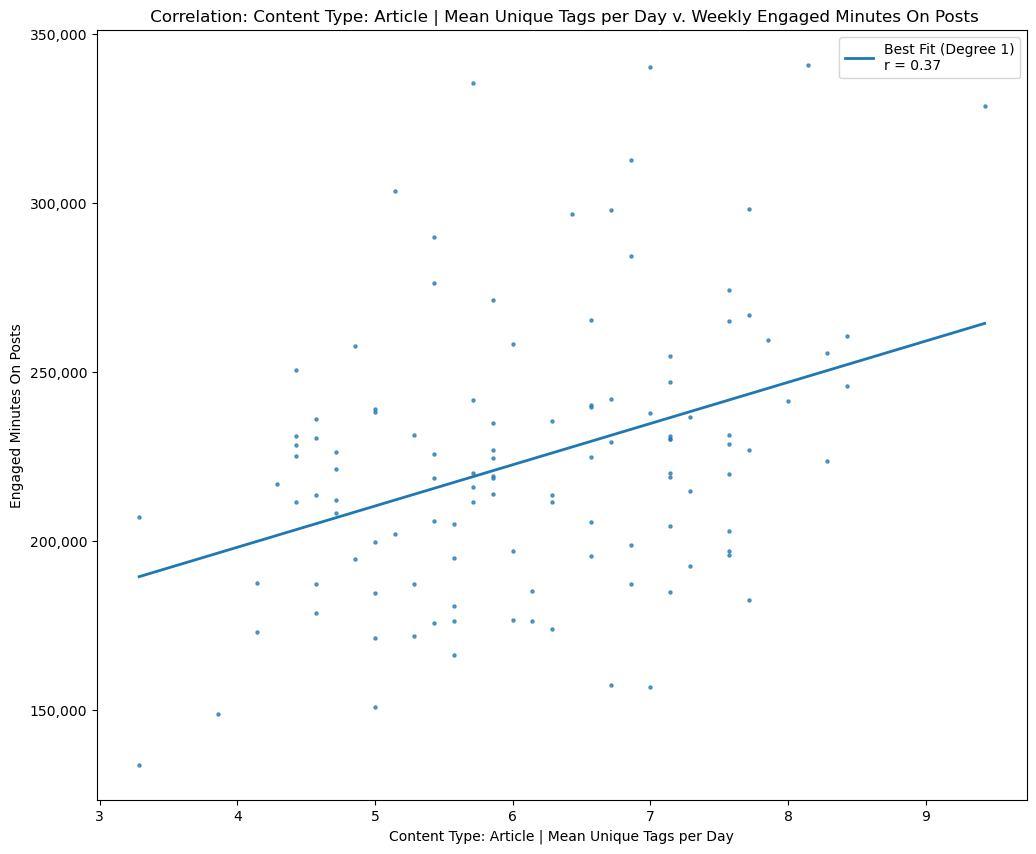

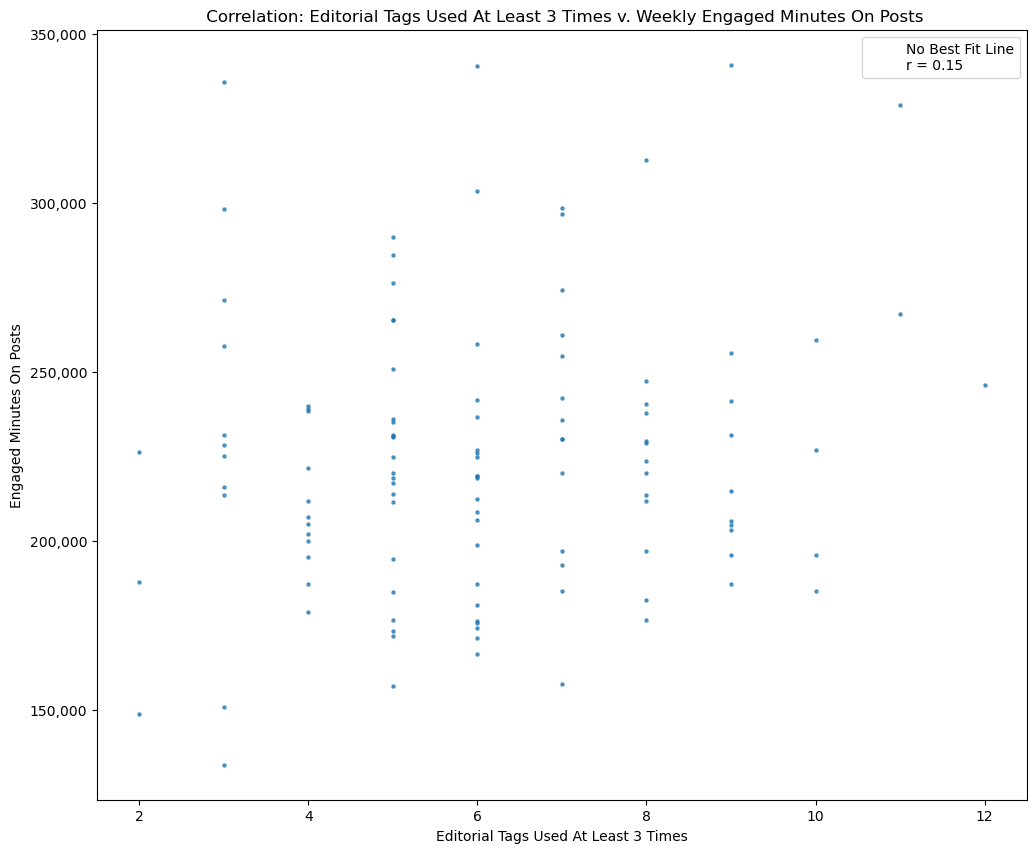

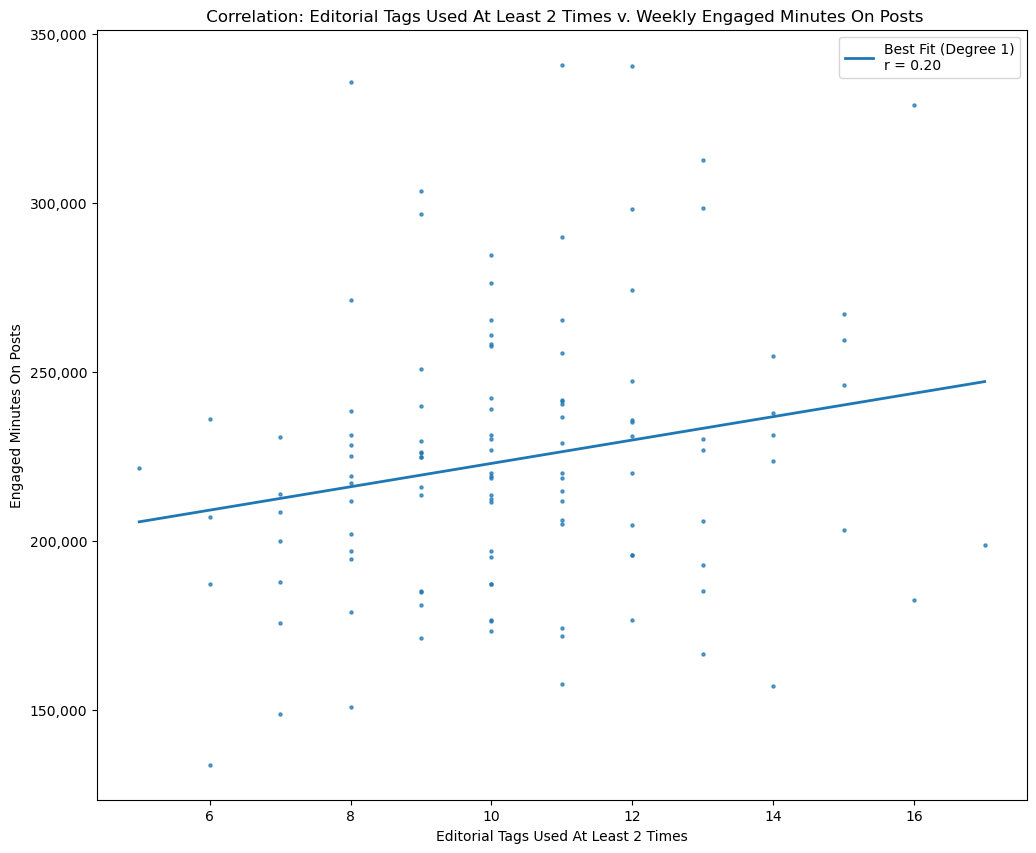

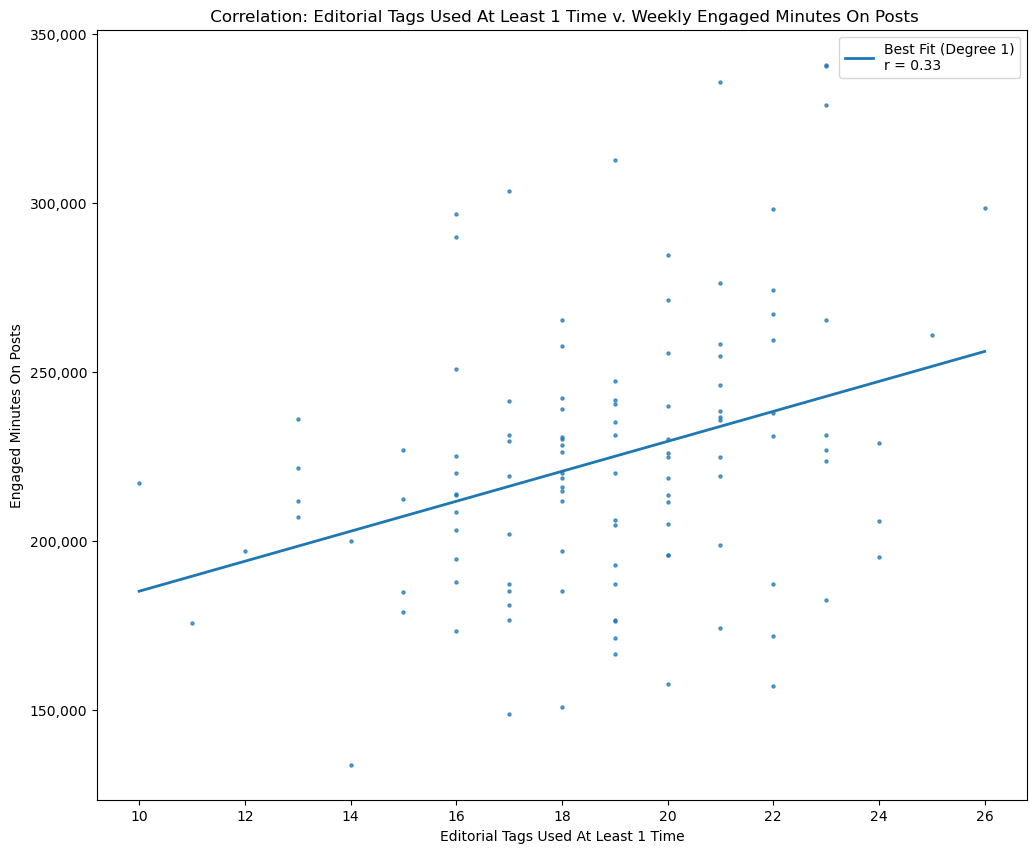

0 rows removed due to outliers in 'Account Registrations'. 115 rows analyzed
                              OLS Regression Results                             
Dep. Variable:     Account Registrations   R-squared:                       0.226
Model:                               OLS   Adj. R-squared:                  0.152
Method:                    Least Squares   F-statistic:                     3.037
Date:                   Tue, 28 Apr 2026   Prob (F-statistic):            0.00206
Time:                           11:08:15   Log-Likelihood:                -913.42
No. Observations:                    115   AIC:                             1849.
Df Residuals:                        104   BIC:                             1879.
Df Model:                             10                                         
Covariance Type:               nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.02

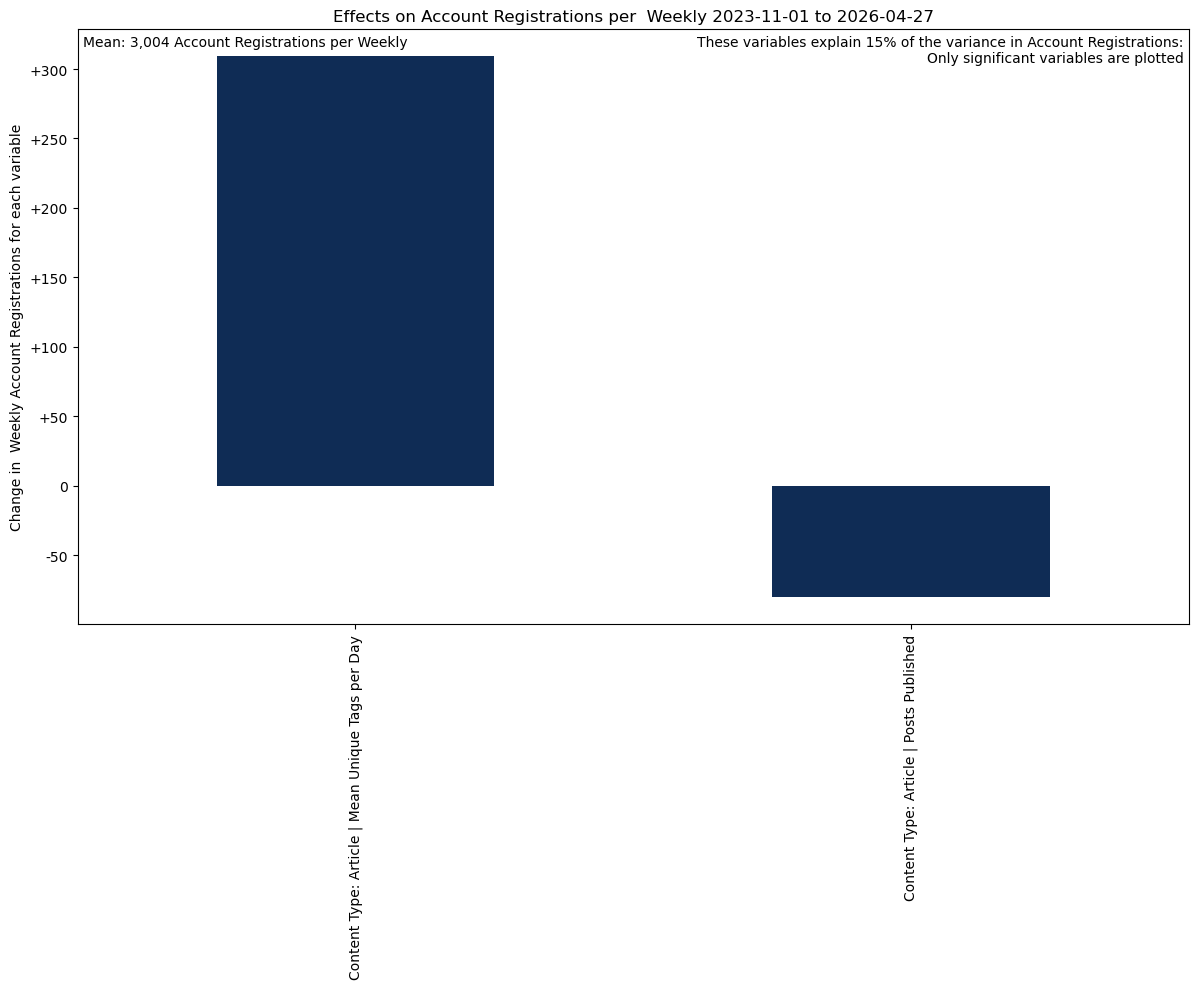

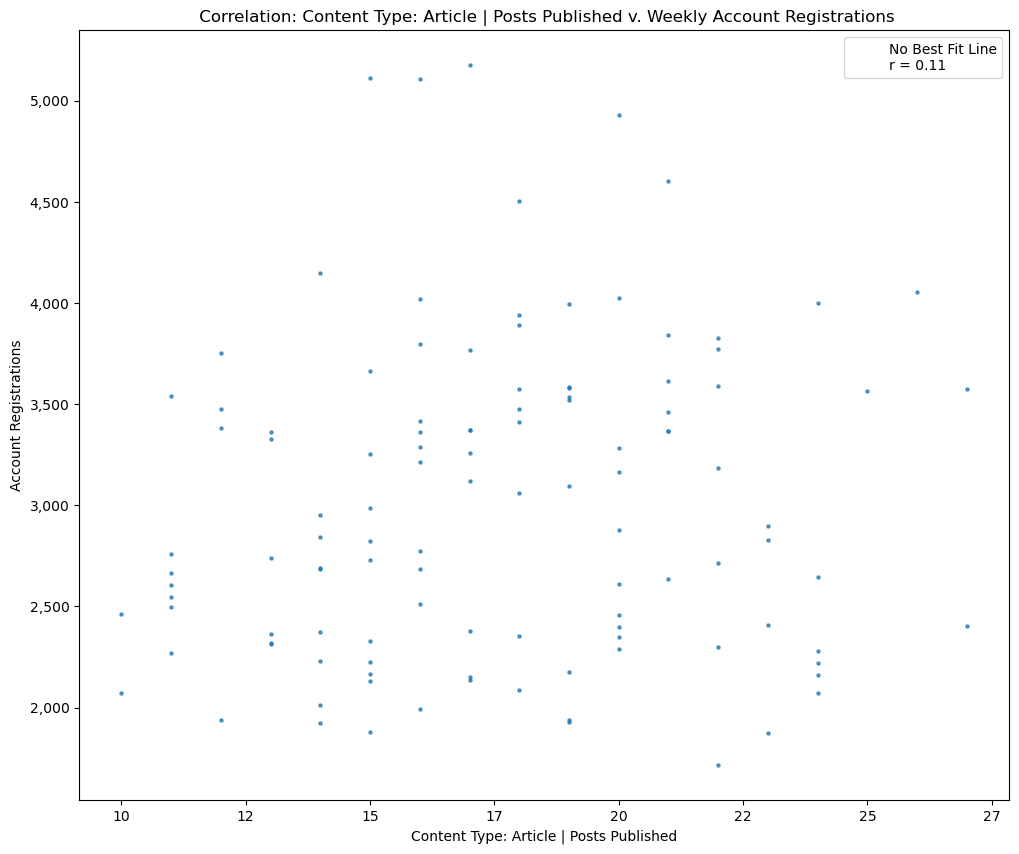

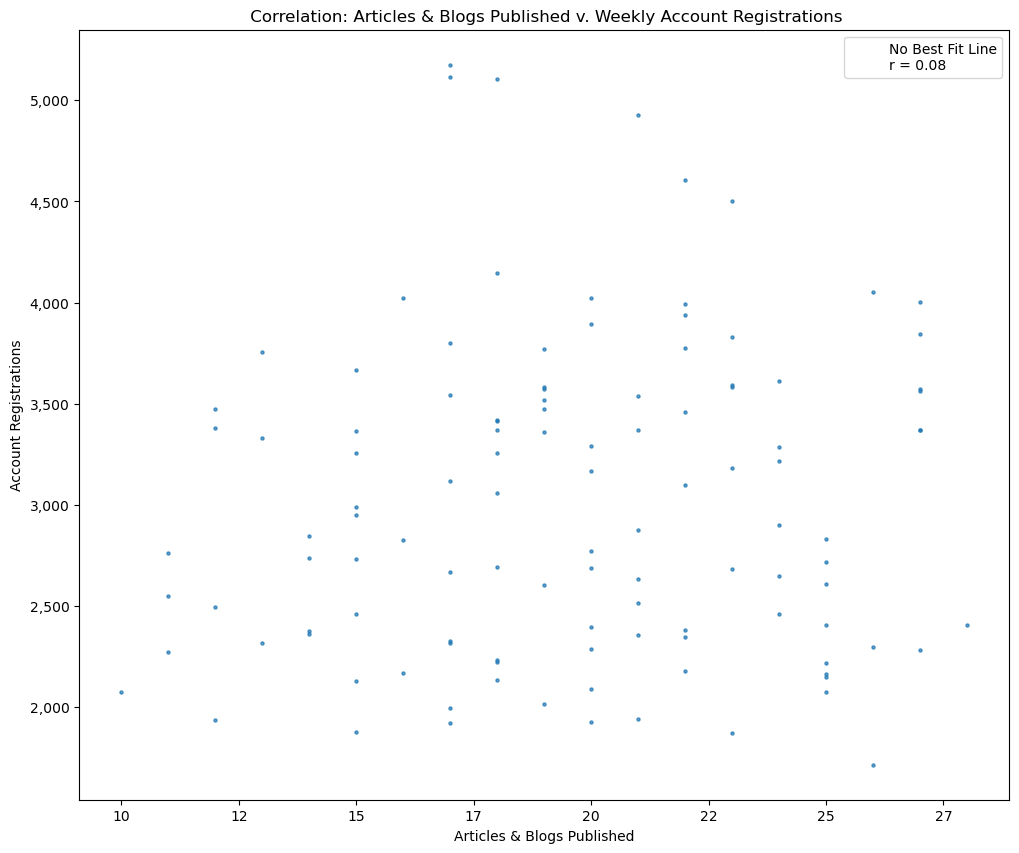

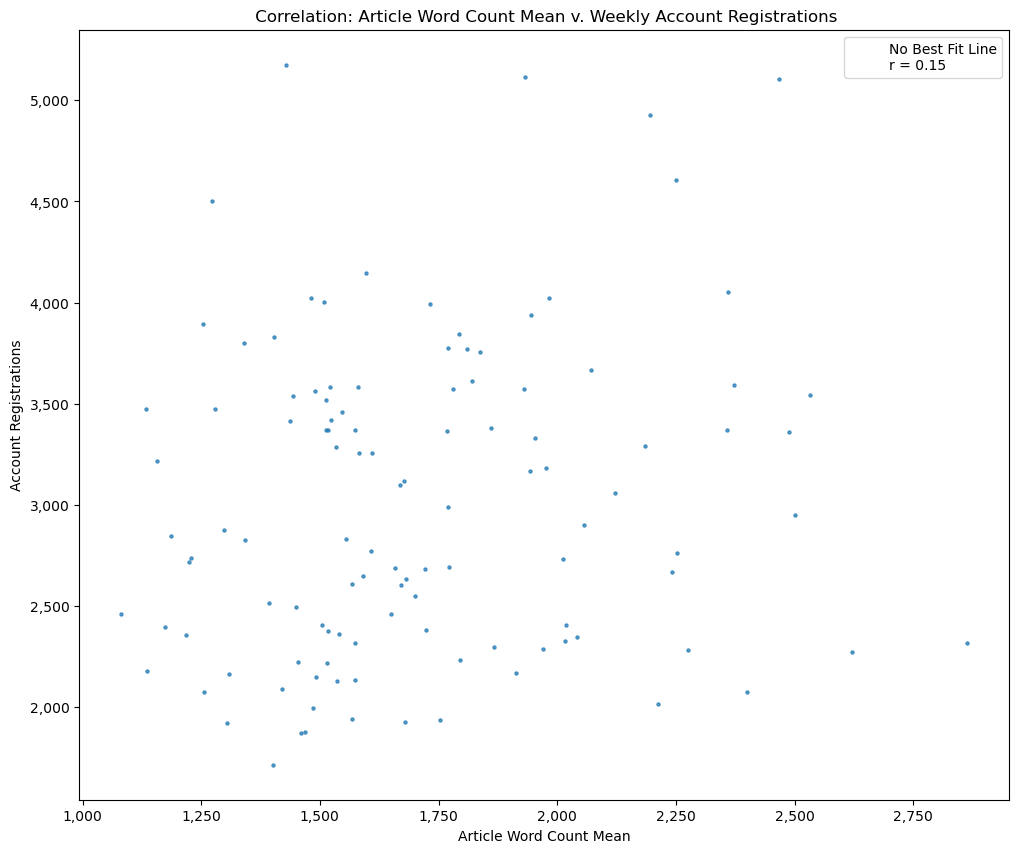

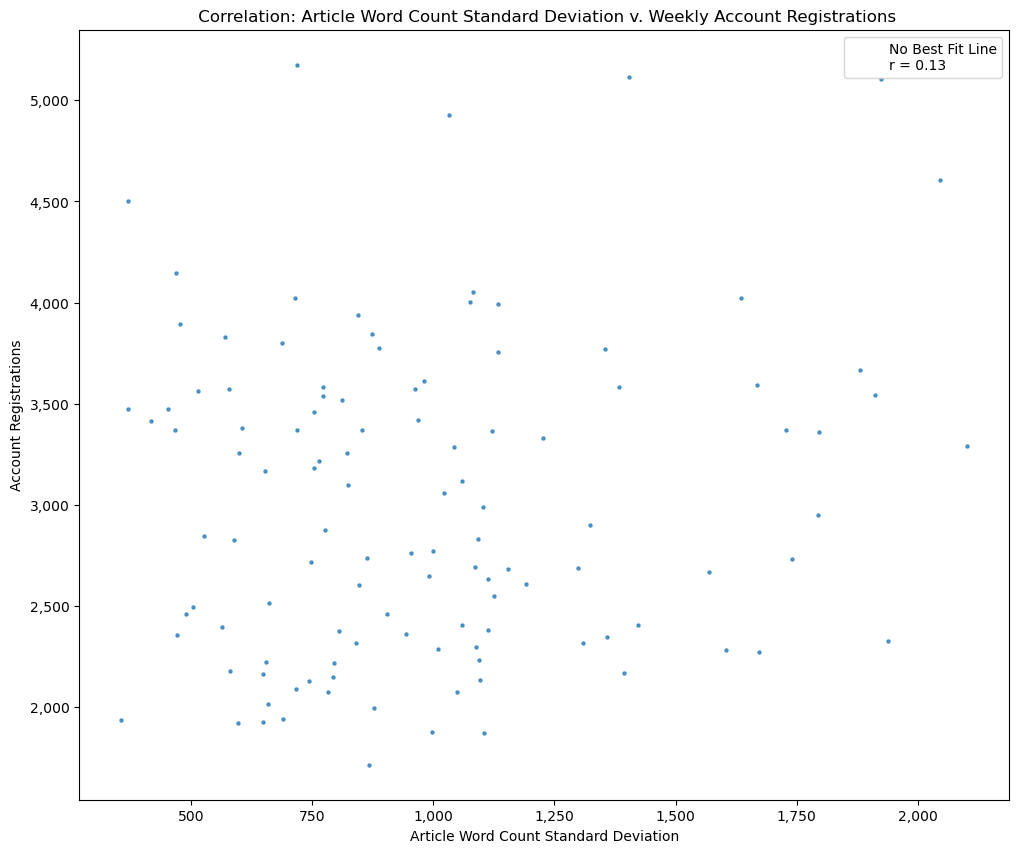

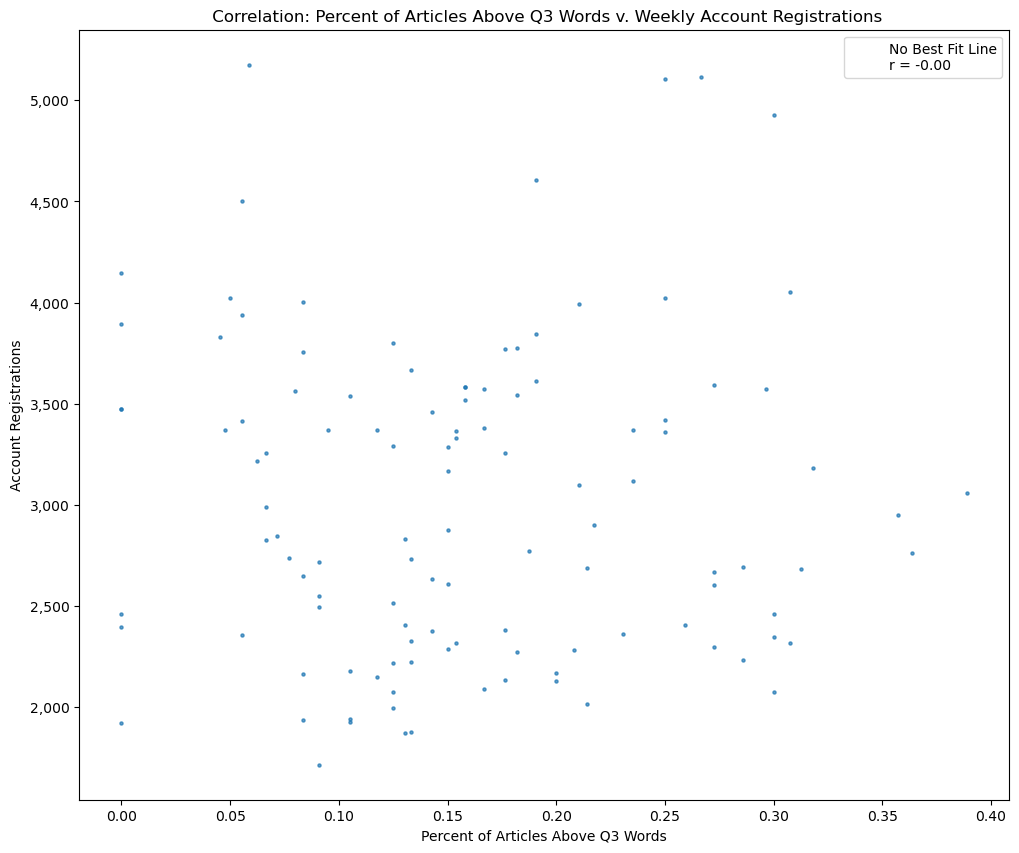

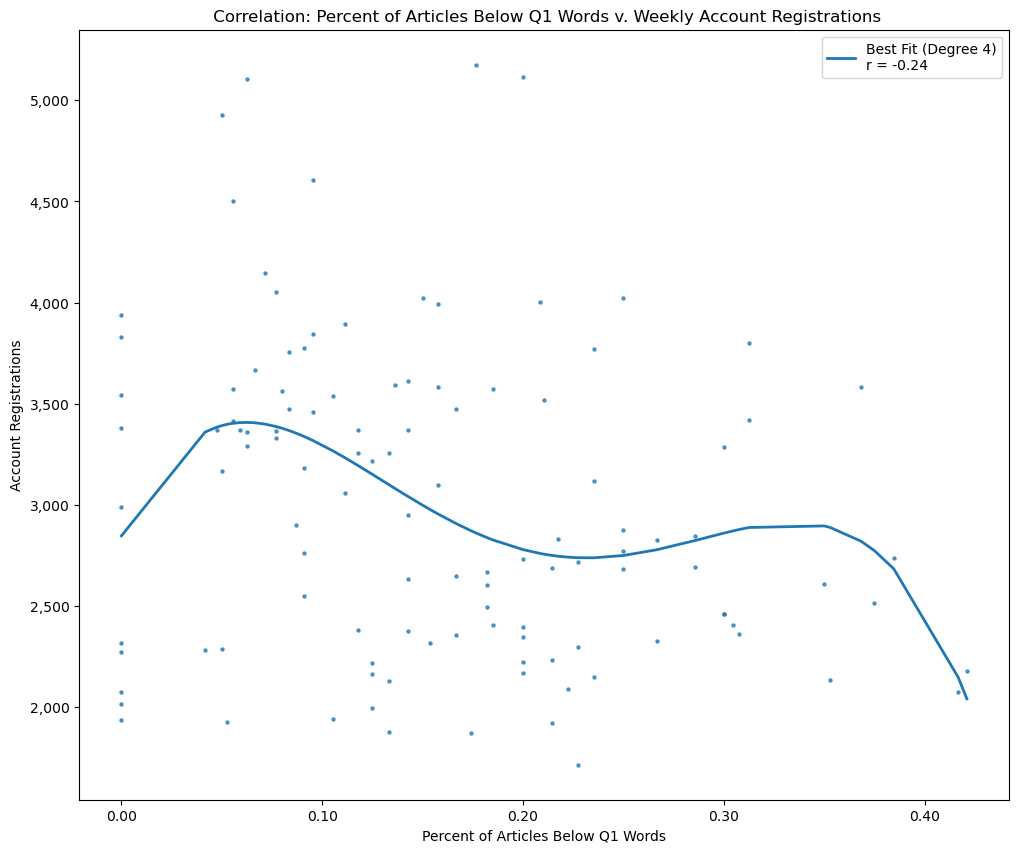

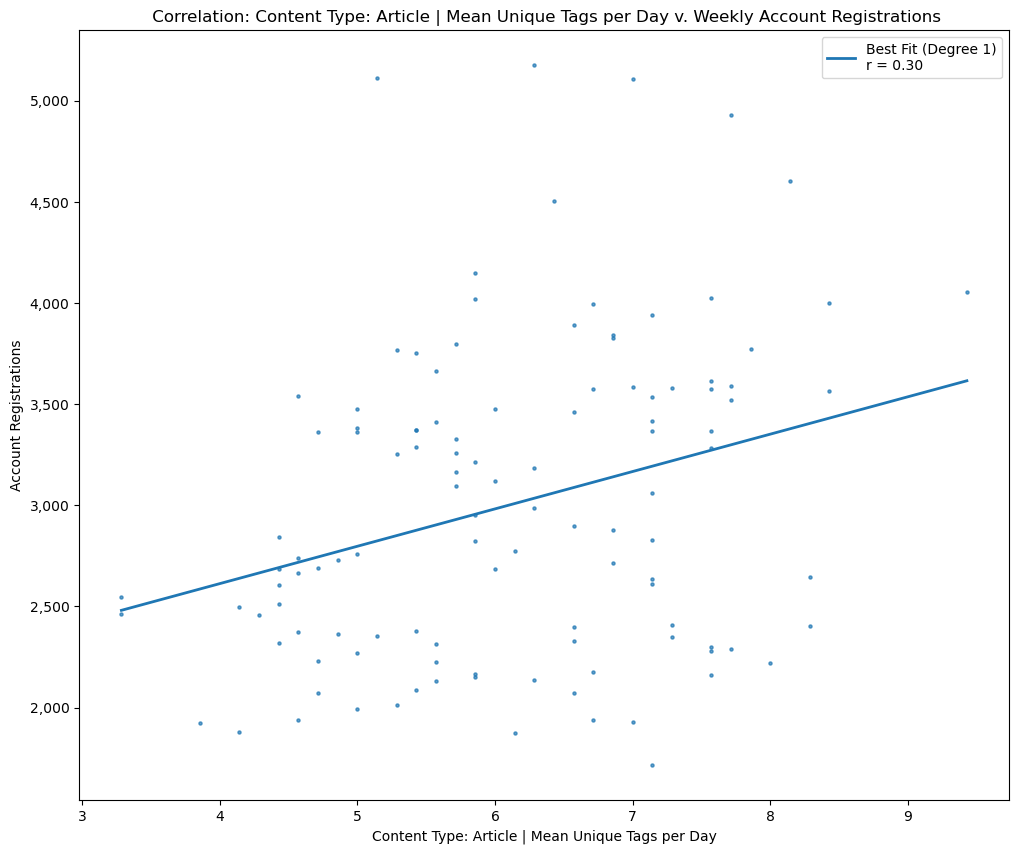

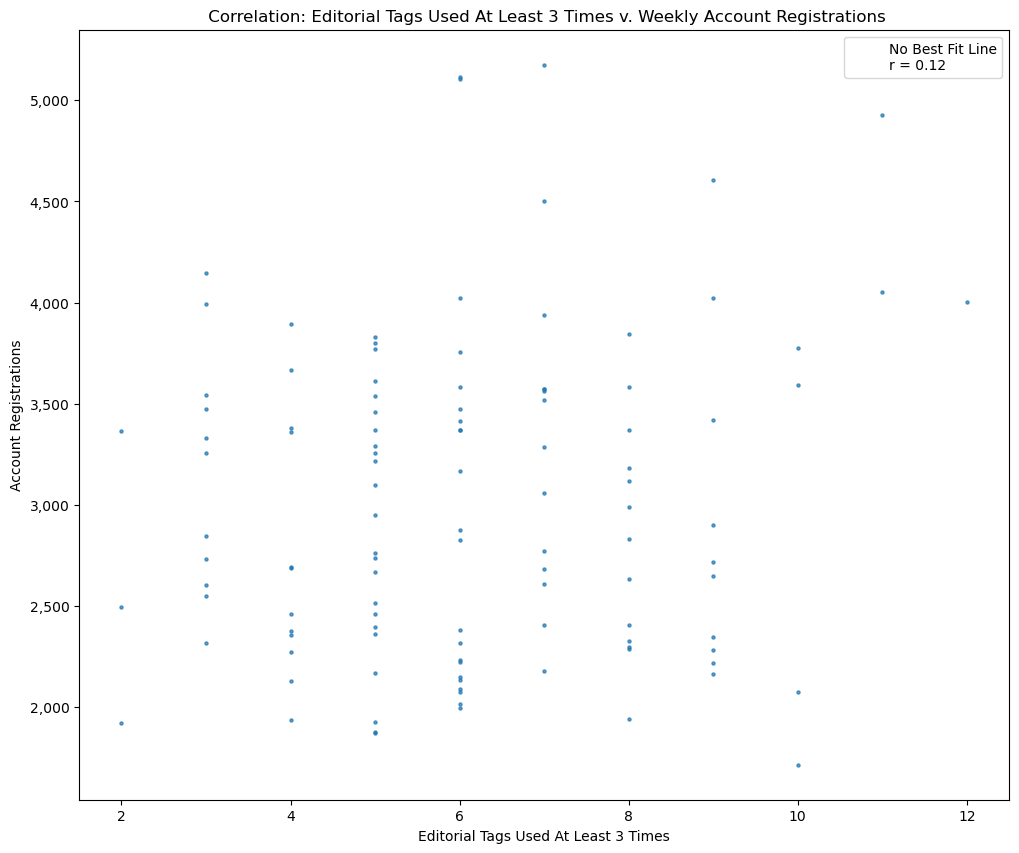

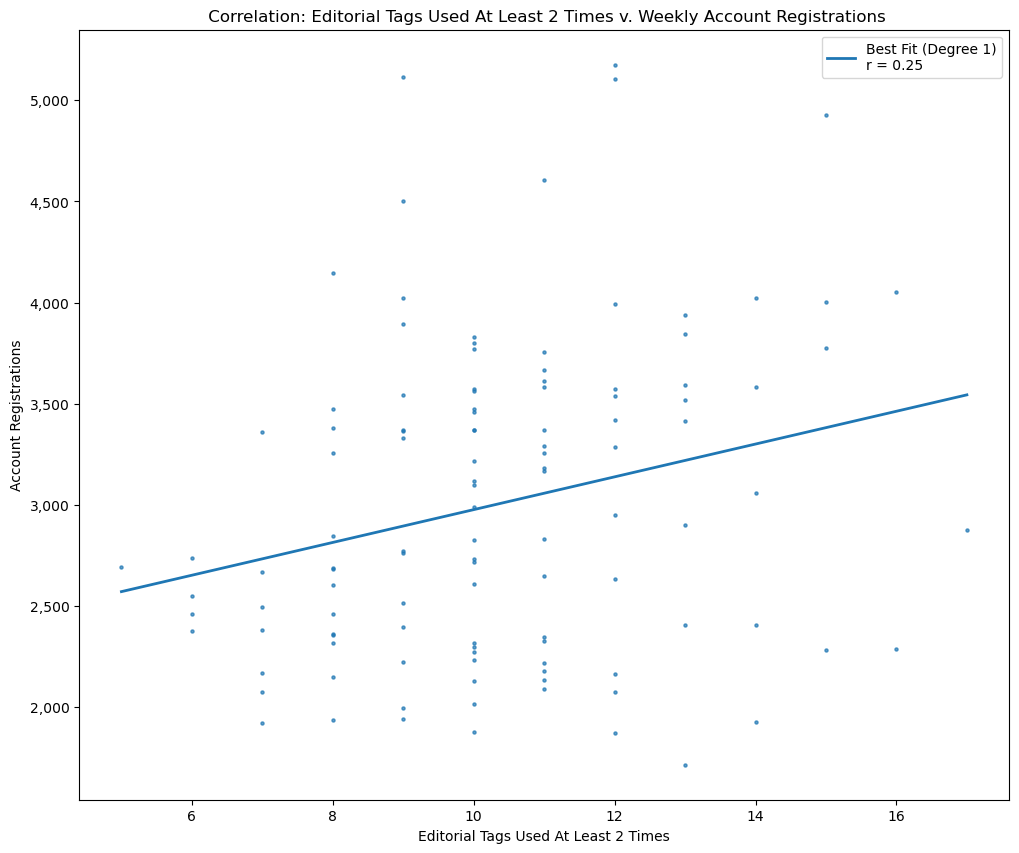

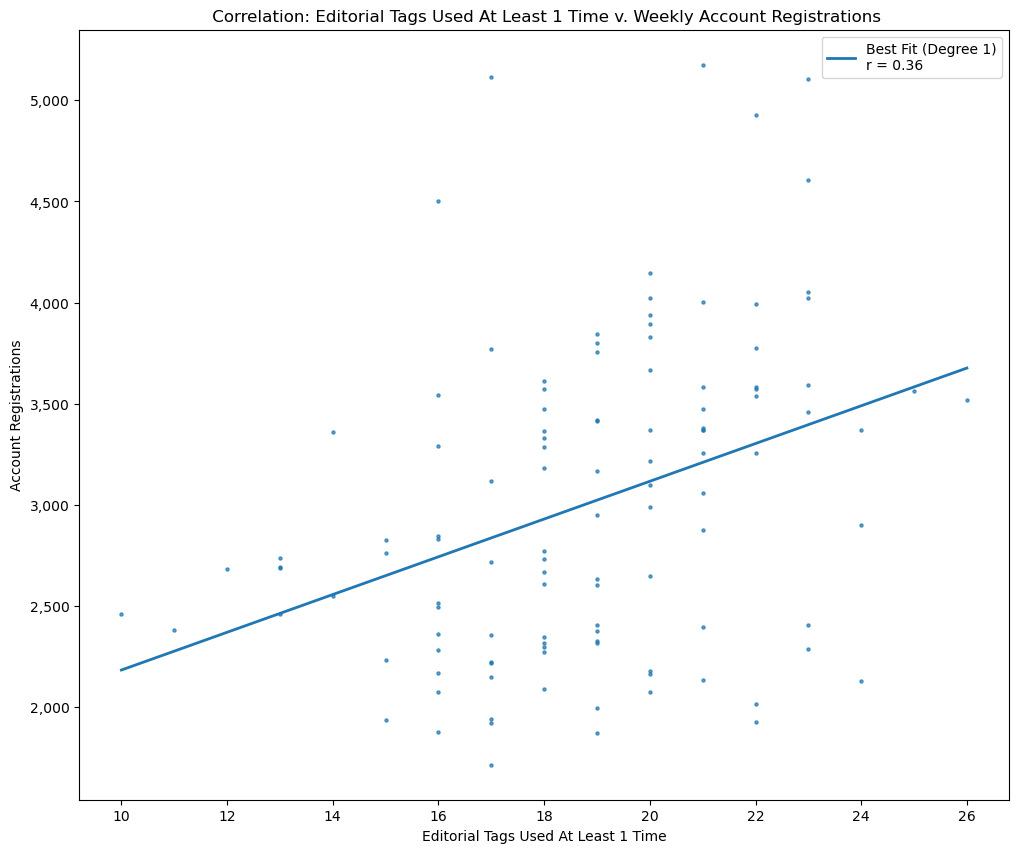

4 rows removed due to outliers in 'Account Registration Efficiency | Linear Conversions'. 111 rows analyzed
                                             OLS Regression Results                                             
Dep. Variable:     Account Registration Efficiency | Linear Conversions   R-squared:                       0.096
Model:                                                              OLS   Adj. R-squared:                  0.006
Method:                                                   Least Squares   F-statistic:                     1.062
Date:                                                  Tue, 28 Apr 2026   Prob (F-statistic):              0.398
Time:                                                          11:08:17   Log-Likelihood:                 447.22
No. Observations:                                                   111   AIC:                            -872.4
Df Residuals:                                                       100   BIC:                       

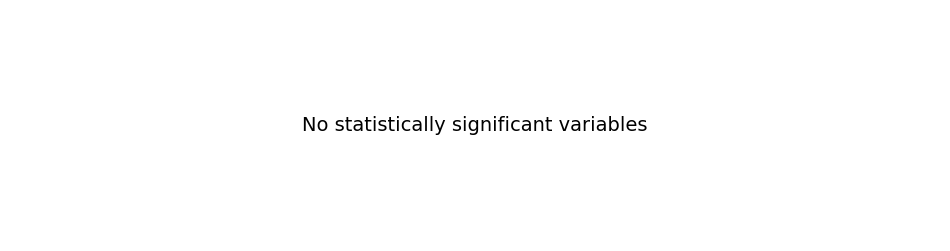

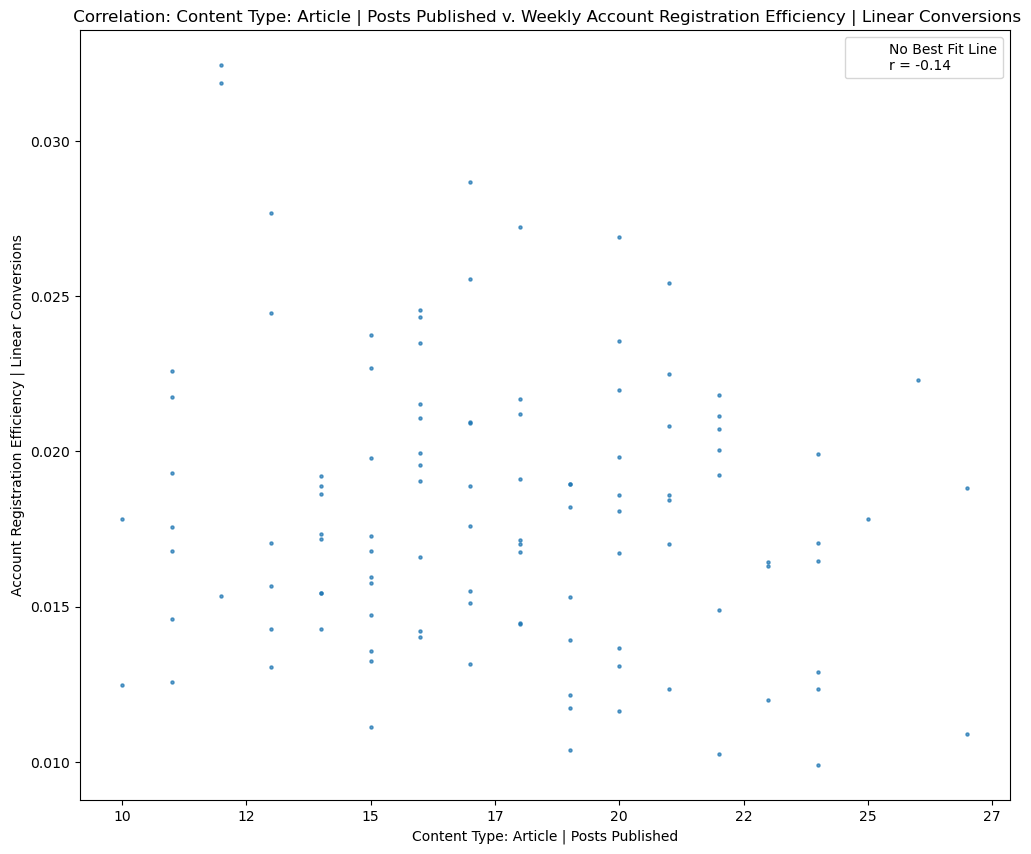

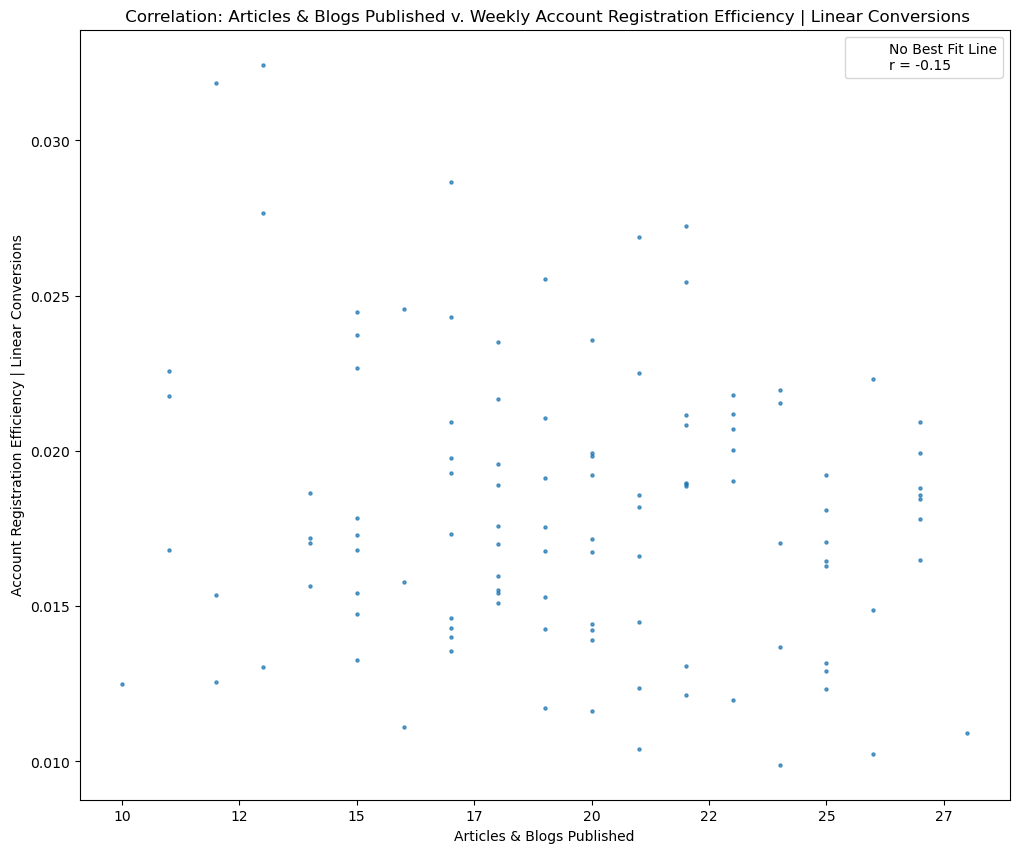

In [ ]:
# ----------------------
# Run the multiple regressions
# ----------------------
multiple_regression_unstandardized(
    df=df,
    target='Weekly',
    dependent_variables=dependent_variables,
    independent_variables=independent_variables,
    start_date=start_date,
    end_date=end_date,
    plot_residuals=False,
    variance_method='semi_partial_standardized',
)

In [ ]:
# ======================
# Example usage
# ======================

best_models_summary, all_model_results, variable_decision_metadata, best_model_objects = find_best_model_with_metadata(
     df=df,
     dependent_variables=dependent_variables,
     independent_variables=independent_variables,
     selection_metric="adjusted_r_squared",  # Options: "adjusted_r_squared", "r_squared", "aic", "bic"
     pvalue_threshold=0.05,
     require_all_predictors_significant=False,
     verbose=True,
 )
#
# To export the metadata:
best_models_summary.to_csv("best_models_summary.csv", index=False)
all_model_results.drop(columns=["model"], errors="ignore").to_csv("all_model_results.csv", index=False)
variable_decision_metadata.to_csv("variable_decision_metadata.csv", index=False)

In [11]:
print(df[independent_variables].mean())

Content Type: Article | Posts Published               17.547826
Articles & Blogs Published                            19.608696
Article Word Count Mean                             1713.854414
Article Word Count Standard Deviation                987.925640
Percent of Articles Above Q3 Words                     0.159095
Percent of Articles Below Q1 Words                     0.157707
Content Type: Article | Mean Unique Tags per Day       6.119255
Editorial Tags Used At Least 3 Times                   6.086957
Editorial Tags Used At Least 2 Times                  10.347826
Editorial Tags Used At Least 1 Time                   18.800000
dtype: float64
